# **Ayudantía 11: Double Machine Learning para Inferencia Causal**

**Curso:** Aplicaciones de Machine Learning en Economía

**Ayudantes:**
- Maykol Medrano — mmedrano2@uc.cl
- Pablo Acevedo — pabloacevedo@uc.cl

En la clase anterior usamos LASSO para selección de variables y BSTS para medir impacto causal en series de tiempo. Hoy damos el paso central del curso: **combinar la flexibilidad de machine learning con la rigurosidad de la inferencia causal econométrica**.

El hilo conductor es una idea simple y poderosa: **partialling out** — remover la influencia de los controles tanto del outcome como del tratamiento, y estimar el efecto causal con la variación limpia que queda. Partimos del resultado clásico (Frisch-Waugh-Lovell) y lo extendemos a modelos no lineales con **Double Machine Learning** (Chernozhukov et al., 2018).

### **Contenidos**

**Parte 1 — El Teorema de Frisch-Waugh-Lovell**

1. **El modelo lineal y el problema de confusión** — sesgo por variable omitida.
2. **FWL: partialling out en tres pasos** — residualizar $Y$ y $D$ respecto a $X$, regresar residuo sobre residuo.
3. **Simulación** — educación, habilidad y salarios. FWL recupera el efecto causal verdadero.

**Parte 2 — Double Machine Learning** 

4. **De FWL a DML** — el modelo parcialmente lineal, ortogonalidad de Neyman, cross-fitting. Conexión con OLS, 2SLS y control function.
5. **DML desde cero** — implementación manual con cross-fitting y Random Forest.
6. **Aplicación económica** — efecto de la elegibilidad a planes 401(k) sobre el ahorro financiero neto (Chernozhukov et al., 2018). Comparamos OLS ingenuo, FWL lineal y DML con múltiples learners.

**Parte 3 — DML con Variables Instrumentales vs 2SLS** 

7. **De 2SLS a DML-IV** — conexión formal entre 2SLS clásico y DML-IV. El mismo instrumento, diferentes supuestos sobre la forma funcional.
8. **Aplicación** — comparamos Wald simple, 2SLS y DML-IV en el problema 401(k).

**Conceptos clave:**
- **Partialling out** — aislar la variación de $D$ que no se explica por los controles $X$.
- **Ortogonalidad de Neyman** — la condición que hace que los errores de ML no sesguen $\hat{\beta}$.
- **Cross-fitting** — separar las muestras de estimación de nuisance y de inferencia final.
- **2SLS vs DML-IV** — misma lógica IV, pero DML relaja la linealidad de la primera etapa.

---

### **¿De dónde venimos?**

| Ayudantía | Método | Concepto central |
|---|---|---|
| **Ay. 1–3** | OLS, Ridge, CV | Regularización L2 — shrinkage pero sin selección |
| **Ay. 5** | Random Forest, XGBoost | Árboles, ensemble methods |
| **Ay. 6** | Perceptrón → MLP | Redes neuronales, representaciones internas |
| **Ay. 8** | Word2Vec, BERT, Ridge | Embeddings — texto como feature para regresión |
| **Ay. 9** | LASSO, BSTS | Alta dimensión y causalidad en series de tiempo |
| **Ay. 10** | FWL, DML | **ML para inferencia causal — partialling out no lineal** |

#### **De predicción a causalidad**

Hasta ahora usamos ML para **predecir**: minimizar el error fuera de muestra. Hoy la pregunta cambia. No queremos predecir $Y$ — queremos estimar **el efecto causal de $D$ sobre $Y$**, controlando por confusores $X$.

El problema es que OLS funciona bien cuando los controles entran linealmente ($g(X) = X'\gamma$), pero falla cuando la relación es no lineal. **DML** resuelve esto: usa ML para modelar $g(X)$ de forma flexible, y dos salvaguardas teóricas (ortogonalidad + cross-fitting) para que la inferencia sobre $\beta$ siga siendo válida.

In [1]:
!pip install doubleml -q  # solo necesario en Colab

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV, LinearRegression
from sklearn.model_selection import KFold, cross_val_predict

import doubleml as dml
from doubleml.datasets import fetch_401K

---

## **Parte 1: El Teorema de Frisch-Waugh-Lovell**

### **1. El problema: sesgo por variable omitida**

Consideremos el modelo lineal multivariado:

$$Y = \beta D + X'\gamma + \varepsilon, \quad \mathbb{E}[\varepsilon \mid D, X] = 0$$

donde:
- $Y$ es la variable de resultado (outcome),
- $D$ es el regresor de interés (tratamiento),
- $X$ es un vector de **controles** (potencialmente de alta dimensión), y
- $\gamma$ es el vector de coeficientes *nuisance* (no nos interesan directamente).

**El coeficiente de interés es $\beta$**: el efecto de $D$ sobre $Y$, manteniendo $X$ constante.

**El desafío:** cuando $X$ está correlacionado con $D$ *y* con $Y$, una regresión simple de $Y$ sobre $D$ produce una estimación sesgada de $\beta$ — el clásico **sesgo por variable omitida (OVB)**.

**Ejemplo:** si queremos estimar el retorno a la educación ($D$) sobre los salarios ($Y$), pero no controlamos por habilidad ($X$), la estimación está inflada porque la habilidad aumenta tanto la educación como los salarios.

### **2. El Teorema de Frisch-Waugh-Lovell**

**Teorema (FWL).** En el modelo lineal $Y = \beta D + X'\gamma + \varepsilon$, el estimador OLS $\hat{\beta}$ es numéricamente idéntico al coeficiente obtenido con el siguiente procedimiento:

**Paso 1.** Regresar $Y$ sobre $X$ por OLS. Obtener residuos $\tilde{Y} = Y - X\hat{\gamma}_Y$.

**Paso 2.** Regresar $D$ sobre $X$ por OLS. Obtener residuos $\tilde{D} = D - X\hat{\gamma}_D$.

**Paso 3.** Regresar $\tilde{Y}$ sobre $\tilde{D}$ por OLS. El coeficiente de pendiente es $\hat{\beta}$.

**Formalmente:**

$$\hat{\beta}_{FWL} = \frac{\sum_{i=1}^{n} \tilde{D}_i \tilde{Y}_i}{\sum_{i=1}^{n} \tilde{D}_i^2} = \frac{\text{Cov}_n(\tilde{D}, \tilde{Y})}{\text{Var}_n(\tilde{D})}$$

**¿Por qué funciona?** FWL dice: *"Remueve la influencia de $X$ de $Y$ y de $D$, y estudia lo que queda."* Los residuos $\tilde{Y}$ y $\tilde{D}$ son ortogonales a $X$ por construcción, así que la regresión $\tilde{Y}$ sobre $\tilde{D}$ está libre del sesgo por variable omitida de $X$.

**Conexión con 2SLS:** FWL es el motor teórico detrás de **2SLS (Two-Stage Least Squares)**. En 2SLS, el primer paso es exactamente un partialling out: se regresan tanto $D$ como los instrumentos $Z$ sobre los controles $X$ para obtener la variación limpia. Si alguna vez implementaron IV/2SLS en Stata (`ivregress 2sls`), lo que ocurre internamente es una secuencia de pasos tipo FWL.

### **3. Simulación: educación → salarios, confundida por habilidad**

**DGP (proceso generador de datos):**

$$Y = \underbrace{0.5}_{\beta} \cdot D + 0.3 \cdot X_1 + 1.5 \cdot X_2 + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

$$D = 12 + 0.8 \cdot X_2 - 0.3 \cdot X_1 + \eta, \quad \eta \sim \mathcal{N}(0, 1)$$

donde:
- $Y$: log salarios (outcome)
- $D$: años de educación (tratamiento)
- $X_1 \sim \mathcal{N}(10, 9)$: experiencia laboral
- $X_2 \sim \mathcal{N}(0, 1)$: habilidad (latente)

**La confusión:** la habilidad ($X_2$) aumenta tanto la educación ($+0.8$) como los salarios ($+1.5$). Omitirla infla la estimación de $\beta$. La experiencia ($X_1$) también genera confusión: más experiencia → menos educación ($-0.3$) pero mayores salarios ($+0.3$).

In [2]:

# DGP: efecto de educacion (D) sobre log salarios (Y)

np.random.seed(42)
n = 1000
TRUE_BETA = 0.5

# Confusores
X1 = np.random.normal(10, 3, n)   # experiencia (añs)
X2 = np.random.normal(0, 1, n)    # habilidad (latente, no observada directamente)

# Tratamiento: educacion depende de habilidad (+) y experiencia (-)
D = 12 + 0.8 * X2 - 0.3 * X1 + np.random.normal(0, 1, n)

# Outcome: log salarios
Y = TRUE_BETA * D + 0.3 * X1 + 1.5 * X2 + np.random.normal(0, 1, n)

# 1. Regresion ingenua: Y ~ D (omite confusores)
naive = sm.OLS(Y, sm.add_constant(D)).fit()

# 2. OLS completo: Y ~ D + X1 + X2
X_full = sm.add_constant(np.column_stack([D, X1, X2]))
full_ols = sm.OLS(Y, X_full).fit()

# 3. FWL: tres pasos de partialling out
X_ctrl = sm.add_constant(np.column_stack([X1, X2]))

# Paso 1: Y sobre controles -> residuos Y_tilde
gamma_Y = np.linalg.lstsq(X_ctrl, Y, rcond=None)[0]
Y_tilde = Y - X_ctrl @ gamma_Y

# Paso 2: D sobre controles -> residuos D_tilde
gamma_D = np.linalg.lstsq(X_ctrl, D, rcond=None)[0]
D_tilde = D - X_ctrl @ gamma_D

# Paso 3: Y_tilde sobre D_tilde
fwl = sm.OLS(Y_tilde, sm.add_constant(D_tilde)).fit()


# Resultados
print('SIMULACION FWL: EDUCACION -> SALARIOS')
print(f'\n  DGP: Y = {TRUE_BETA}*D + 0.3*X1 + 1.5*X2 + eps')
print(f'       D = 12 + 0.8*X2 - 0.3*X1 + eta')
print(f'       n = {n},  beta verdadero = {TRUE_BETA}')

print(f'\n  {"Metodo":<28} {"Estimacion":>12} {"SE":>10} {"Sesgo":>10}')

print(f'  {"beta verdadero":<28} {TRUE_BETA:>12.4f}')
print(f'  {"Ingenuo (Y ~ D)":<28} {naive.params[1]:>12.4f} {naive.bse[1]:>10.4f} {naive.params[1]-TRUE_BETA:>+10.4f}')
print(f'  {"OLS completo (Y ~ D + X)":<28} {full_ols.params[1]:>12.4f} {full_ols.bse[1]:>10.4f} {full_ols.params[1]-TRUE_BETA:>+10.4f}')
print(f'  {"FWL (3 pasos)":<28} {fwl.params[1]:>12.4f} {fwl.bse[1]:>10.4f} {fwl.params[1]-TRUE_BETA:>+10.4f}')

print(f'\n  |beta_OLS - beta_FWL| = {abs(full_ols.params[1] - fwl.params[1]):.2e}  (numericamente identicos)')

print(f'\n  Por que el ingenuo esta sesgado:')
print(f'    Corr(D, X2) = {np.corrcoef(D, X2)[0,1]:+.3f}  (educacion <-> habilidad)')
print(f'    Corr(Y, X2) = {np.corrcoef(Y, X2)[0,1]:+.3f}  (salarios <-> habilidad)')
print(f'    => OVB positivo: omitir habilidad infla la estimacion')

SIMULACION FWL: EDUCACION -> SALARIOS

  DGP: Y = 0.5*D + 0.3*X1 + 1.5*X2 + eps
       D = 12 + 0.8*X2 - 0.3*X1 + eta
       n = 1000,  beta verdadero = 0.5

  Metodo                         Estimacion         SE      Sesgo
  beta verdadero                     0.5000
  Ingenuo (Y ~ D)                    0.6822     0.0394    +0.1822
  OLS completo (Y ~ D + X)           0.5223     0.0330    +0.0223
  FWL (3 pasos)                      0.5223     0.0330    +0.0223

  |beta_OLS - beta_FWL| = 1.22e-15  (numericamente identicos)

  Por que el ingenuo esta sesgado:
    Corr(D, X2) = +0.533  (educacion <-> habilidad)
    Corr(Y, X2) = +0.829  (salarios <-> habilidad)
    => OVB positivo: omitir habilidad infla la estimacion


**Visualización:** el panel izquierdo muestra la regresión ingenua ($Y$ vs $D$) — la pendiente está inflada por la confusión de habilidad. El panel derecho muestra la regresión FWL ($\tilde{Y}$ vs $\tilde{D}$) — la variación limpia, libre de confusores.

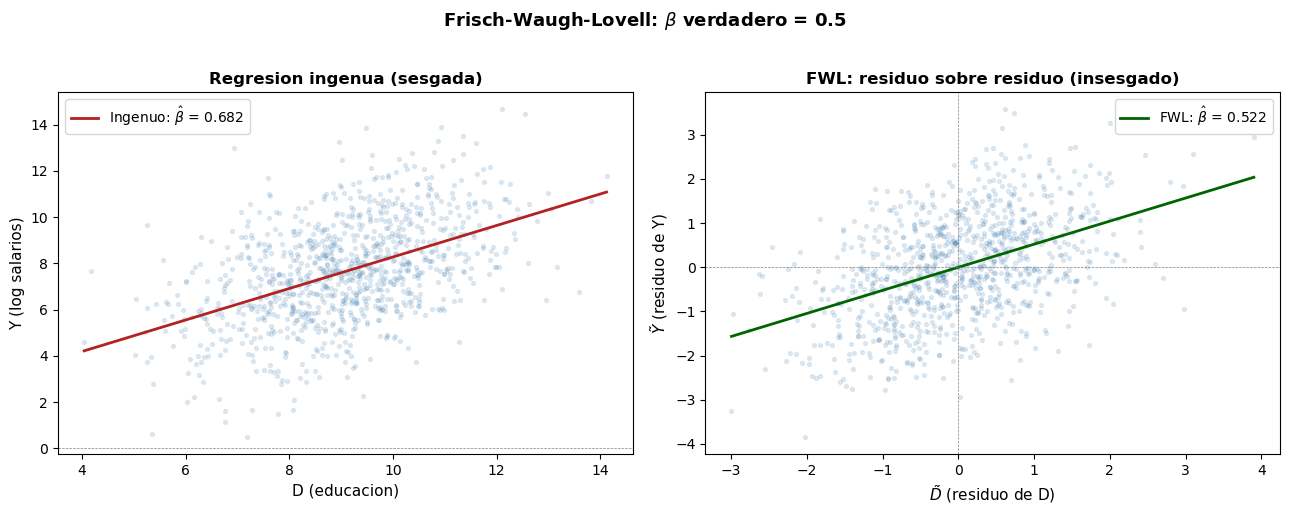

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: regresion ingenua
axes[0].scatter(D, Y, alpha=0.15, s=8, color='steelblue')
x_line = np.linspace(D.min(), D.max(), 100)
axes[0].plot(x_line, naive.params[0] + naive.params[1] * x_line,
             color='firebrick', linewidth=2, label=f'Ingenuo: $\\hat{{\\beta}}$ = {naive.params[1]:.3f}')
axes[0].axhline(y=0, color='grey', linewidth=0.5, linestyle='--')
axes[0].set_xlabel('D (educacion)', fontsize=11)
axes[0].set_ylabel('Y (log salarios)', fontsize=11)
axes[0].set_title('Regresion ingenua (sesgada)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Panel derecho: FWL (residuo sobre residuo)
axes[1].scatter(D_tilde, Y_tilde, alpha=0.15, s=8, color='steelblue')
x_line2 = np.linspace(D_tilde.min(), D_tilde.max(), 100)
axes[1].plot(x_line2, fwl.params[0] + fwl.params[1] * x_line2,
             color='darkgreen', linewidth=2, label=f'FWL: $\\hat{{\\beta}}$ = {fwl.params[1]:.3f}')
axes[1].axhline(y=0, color='grey', linewidth=0.5, linestyle='--')
axes[1].axvline(x=0, color='grey', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('$\\tilde{D}$ (residuo de D)', fontsize=11)
axes[1].set_ylabel('$\\tilde{Y}$ (residuo de Y)', fontsize=11)
axes[1].set_title('FWL: residuo sobre residuo (insesgado)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

fig.suptitle(f'Frisch-Waugh-Lovell: $\\beta$ verdadero = {TRUE_BETA}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## **Parte 2: Double Machine Learning**

### **4. De FWL a DML: el modelo parcialmente lineal**

FWL funciona perfectamente cuando los controles entran **linealmente**: $g(X) = X'\gamma$. Pero en la realidad económica, la relación entre controles y outcomes es frecuentemente **no lineal**.

**Ejemplo:** el efecto del ingreso sobre el consumo no es lineal — hay rendimientos marginales decrecientes, umbrales de pobreza, efectos de interacción con educación y composición familiar.

**El modelo parcialmente lineal (PLM)** generaliza el modelo lineal:

$$Y = \beta D + g(X) + \varepsilon, \quad \mathbb{E}[\varepsilon \mid D, X] = 0$$

donde $g(X)$ es una función **completamente no lineal** de los controles. El coeficiente de interés sigue siendo $\beta$ — el efecto (causal, bajo los supuestos de identificación) de $D$ sobre $Y$.

**La misma lógica de partialling out aplica:**

$$\tilde{Y} = Y - \ell(X), \quad \tilde{D} = D - m(X)$$

donde $\ell(X) = \mathbb{E}[Y \mid X]$ y $m(X) = \mathbb{E}[D \mid X]$. Entonces:

$$\tilde{Y} = \beta \tilde{D} + \varepsilon, \quad \mathbb{E}[\varepsilon \tilde{D}] = 0$$

**La diferencia con FWL:** ahora $\ell(X)$ y $m(X)$ se estiman con **ML** (Random Forest, Boosting, etc.) en vez de OLS.

| | **FWL (lineal)** | **DML (no lineal)** |
|---|---|---|
| Modelo | $Y = \beta D + X'\gamma + \varepsilon$ | $Y = \beta D + g(X) + \varepsilon$ |
| Partialling out | OLS | ML (forests, boosting, redes) |
| $g(X)$ | $X'\gamma$ (lineal) | Cualquier función no lineal |
| Inferencia | Estándar | Estándar (**si** ortogonalidad + cross-fitting) |

### **FWL como base de la econometría aplicada**

FWL no es solo un teorema elegante — es la **maquinaria interna** de los estimadores econométricos más usados. Veamos cómo se conecta con los métodos que ya conocen:

| Método econométrico | Qué hace | Relación con FWL |
|---|---|---|
| **OLS multivariado** | $Y = \beta D + X'\gamma + \varepsilon$ | FWL demuestra que $\hat{\beta}$ depende solo de los residuos $\tilde{Y}, \tilde{D}$ |
| **2SLS** | Etapa 1: $D = X'\gamma + Z'\pi + \nu$; Etapa 2: $Y = \hat{D}\beta + X'\delta + \varepsilon$ | La primera etapa es FWL: residualizar $D$ y $Z$ respecto a $X$ |
| **Control function** | Incluir $\hat{\nu}$ de la etapa 1 como regresor | Equivalente a FWL bajo homocedasticidad (Wooldridge, 2015) |
| **DML** | Reemplazar OLS por ML en los pasos de FWL | **Generalización no lineal de FWL** — el tema de hoy |

**La limitación común:** todos estos métodos (excepto DML) asumen que la relación entre $X$ y las variables de interés es **lineal**. Si $g(X)$ es no lineal, OLS, 2SLS y control function producen estimaciones sesgadas por la mala especificación de la primera etapa.

### **Ortogonalidad de Neyman: ¿por qué no basta con usar ML directamente?**

Si simplemente reemplazamos OLS por ML en FWL, **la inferencia se rompe**. ¿Por qué?

**El problema:** los estimadores ML tienen sesgo de regularización. En FWL lineal, los errores de estimación de $\hat{\gamma}_Y$ y $\hat{\gamma}_D$ se cancelan exactamente (es un resultado algebraico de la proyección lineal). Con ML, esa cancelación no ocurre automáticamente — los errores en $\hat{\ell}(X)$ y $\hat{m}(X)$ contaminan $\hat{\beta}$.

**La solución: ortogonalidad de Neyman.** DML construye una ecuación de momento que es **localmente insensible** a perturbaciones en las funciones nuisance. El sesgo resultante tiene estructura **multiplicativa**:

$$\text{Sesgo} \approx \|\hat{\ell} - \ell\|_{L_2} \cdot \|\hat{m} - m\|_{L_2}$$

Esto es clave: los errores de ML en $\ell$ y $m$ se **multiplican**, no se suman. Si cada estimador converge a tasa $n^{-1/4}$:

$$n^{1/2} \cdot n^{-1/4} \cdot n^{-1/4} = n^{1/2} \cdot n^{-1/2} = 1 \to 0$$

**Resultado:** $\sqrt{n}(\hat{\beta} - \beta) \xrightarrow{d} \mathcal{N}(0, V)$ — inferencia estándar, como si las funciones nuisance fueran conocidas.

**Implicación práctica:** muchos métodos ML (forests, boosting, redes) alcanzan tasas $n^{-1/4}$ bajo condiciones suaves. No necesitamos que ML sea perfecto — solo suficientemente bueno.

### **Cross-fitting: ¿por qué separar las muestras?**

Incluso con ortogonalidad de Neyman, hay un segundo problema: si estimamos $\hat{\ell}(X)$ y $\hat{m}(X)$ en la **misma muestra** donde hacemos la inferencia final, el overfitting de ML introduce un sesgo adicional.

**El mecanismo:** ML captura no solo la señal en los datos, sino también ruido idiosincrático. Si reutilizamos esas predicciones en la ecuación estimante, el ruido se correlaciona con el error $\varepsilon$, creando endogeneidad artificial.

**Solución: cross-fitting** (análogo al cross-validation).

**Algoritmo DML completo:**

1. **Particionar** los datos en $K$ folds de tamaño aproximadamente igual: $\{1, \ldots, n\} = \bigcup_{k=1}^{K} I_k$.

2. **Para cada fold $k$:** entrenar $\hat{\ell}_{-k}$ y $\hat{m}_{-k}$ con todas las observaciones **excepto** el fold $k$. Computar residuos cross-fitted:

$$\tilde{Y}_i = Y_i - \hat{\ell}_{-k}(X_i), \quad \tilde{D}_i = D_i - \hat{m}_{-k}(X_i), \quad i \in I_k$$

3. **OLS final:** estimar $\hat{\beta}$ por OLS de $\tilde{Y}_i$ sobre $\tilde{D}_i$.

4. **Inferencia:** errores estándar e intervalos de confianza como en OLS estándar.

**Resumen de los dos ingredientes:**
- **Ortogonalidad** → controla el sesgo de aproximación de ML
- **Cross-fitting** → controla el sesgo por overfitting

### **5. Aplicación económica: planes 401(k) y ahorro financiero**

**Pregunta de investigación:** ¿cuánto aumentan los activos financieros netos de un hogar cuando tiene acceso a un plan de pensiones 401(k)?

**Contexto:** los planes 401(k) son planes de ahorro para la jubilación con ventajas tributarias en EE.UU. La elegibilidad depende del empleador — no todos los trabajadores tienen acceso.

**El problema causal:** los hogares elegibles para 401(k) difieren sistemáticamente de los no elegibles en ingreso, educación, edad, composición familiar, etc. Una regresión ingenua de activos sobre elegibilidad sobreestima el efecto porque captura tanto el efecto del plan como las diferencias preexistentes.

**Datos:** encuesta SIPP (Survey of Income and Program Participation), 9.915 hogares.

| Variable | Descripción |
|---|---|
| `net_tfa` | Activos financieros totales netos (USD) — **outcome** $Y$ |
| `e401` | Elegibilidad para 401(k) (0/1) — **tratamiento** $D$ |
| `p401` | Participación en 401(k) (0/1) — tratamiento endógeno en Parte 3 |
| `age` | Edad del jefe de hogar |
| `inc` | Ingreso familiar |
| `educ` | Años de educación |
| `fsize` | Tamaño del hogar |
| `marr` | Casado/a (0/1) |
| `twoearn` | Dos ingresos en el hogar (0/1) |
| `db` | Tiene plan de beneficio definido (0/1) |
| `pira` | Tiene IRA (cuenta individual de retiro, 0/1) |
| `hown` | Es dueño de vivienda (0/1) |

In [4]:
# Cargar datos 401(k) del paquete doubleml

data_401k = fetch_401K(polynomial_features=False)
df = data_401k.data

x_cols = ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']

print(f'Observaciones: {len(df):,}')
print(f'Outcome (Y):   net_tfa  (activos financieros netos, USD)')
print(f'Tratamiento (D): e401  (elegibilidad 401k)')
print(f'Controles (X): {x_cols}')
print()

# Estadisticas descriptivas por grupo de tratamiento
summary = df.groupby('e401')[['net_tfa', 'inc', 'age', 'educ']].mean()
summary.index = ['No elegible', 'Elegible']
summary.columns = ['Activos netos (USD)', 'Ingreso (USD)', 'Edad', 'Educacion']
print('Medias por grupo de tratamiento:')
print(summary.round(0).to_string())
print()
print('Diferencia bruta en activos: '
      f'{df.loc[df.e401==1, "net_tfa"].mean() - df.loc[df.e401==0, "net_tfa"].mean():,.0f} USD')

Observaciones: 9,915
Outcome (Y):   net_tfa  (activos financieros netos, USD)
Tratamiento (D): e401  (elegibilidad 401k)
Controles (X): ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']

Medias por grupo de tratamiento:
             Activos netos (USD)  Ingreso (USD)  Edad  Educacion
No elegible              10788.0        31494.0  41.0       13.0
Elegible                 30347.0        46862.0  41.0       14.0

Diferencia bruta en activos: 19,559 USD


**El sesgo de selección es evidente:** los hogares elegibles tienen en promedio mayor ingreso, mayor educación y mayor edad. La diferencia bruta de ~\$19.500 mezcla el efecto causal del plan 401(k) con las diferencias preexistentes entre los grupos.

Ahora comparamos tres estrategias para aislar el efecto causal:
1. **Ingenuo** — regresión simple $Y \sim D$
2. **FWL lineal** — partialling out con OLS
3. **DML** — partialling out con ML + cross-fitting

In [5]:

# Paso 1: Regresion ingenua (Y ~ D, sin controles)
Y = df['net_tfa'].values
D = df['e401'].values
X = df[x_cols].values

naive_ols = sm.OLS(Y, sm.add_constant(D)).fit(cov_type='HC1')


# Paso 2: FWL con OLS (partialling out lineal)
X_const = sm.add_constant(X)

# Paso 2a: Y sobre controles -> residuos
gamma_Y = np.linalg.lstsq(X_const, Y, rcond=None)[0]
Y_res_ols = Y - X_const @ gamma_Y

# Paso 2b: D sobre controles -> residuos
gamma_D = np.linalg.lstsq(X_const, D, rcond=None)[0]
D_res_ols = D - X_const @ gamma_D

# Paso 2c: Y_tilde sobre D_tilde
fwl_ols = sm.OLS(Y_res_ols, sm.add_constant(D_res_ols)).fit(cov_type='HC1')

print('COMPARACION: INGENUO vs FWL LINEAL')
print(f'\n  {"Metodo":<30} {"beta":>10} {"SE":>10} {"IC 95%":>24}')
ci_naive = naive_ols.conf_int()[1]
ci_fwl   = fwl_ols.conf_int()[1]
print(f'  {"Ingenuo (Y ~ D)":<30} {naive_ols.params[1]:>10,.0f} {naive_ols.bse[1]:>10,.0f}'
      f'  [{ci_naive[0]:>10,.0f}, {ci_naive[1]:>10,.0f}]')
print(f'  {"FWL lineal":<30} {fwl_ols.params[1]:>10,.0f} {fwl_ols.bse[1]:>10,.0f}'
      f'  [{ci_fwl[0]:>10,.0f}, {ci_fwl[1]:>10,.0f}]')
print(f'\n  FWL reduce la estimacion de {naive_ols.params[1]:,.0f} a {fwl_ols.params[1]:,.0f} USD')
print(f'  => Controlar por observables ya elimina mucho sesgo.')
print(f'  Pero FWL asume g(X) = X\'gamma. Que pasa si g(X) es no lineal?')

COMPARACION: INGENUO vs FWL LINEAL

  Metodo                               beta         SE                   IC 95%
  Ingenuo (Y ~ D)                    19,559      1,413  [    16,790,     22,329]
  FWL lineal                          5,896      1,523  [     2,911,      8,882]

  FWL reduce la estimacion de 19,559 a 5,896 USD
  => Controlar por observables ya elimina mucho sesgo.
  Pero FWL asume g(X) = X'gamma. Que pasa si g(X) es no lineal?


### **6. DML desde cero — implementación manual**

Antes de usar el paquete `doubleml`, implementamos el algoritmo DML paso a paso para entender cada componente. Usamos **Random Forest** como learner para las funciones nuisance $\ell(X) = \mathbb{E}[Y \mid X]$ y $m(X) = \mathbb{E}[D \mid X]$.

In [6]:

# DML MANUAL: partialling out con Random Forest + cross-fitting
np.random.seed(42)
K = 5  # numero de folds

# Crear folds para cross-fitting
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Arrays para almacenar residuos cross-fitted
Y_tilde = np.zeros(len(Y))
D_tilde = np.zeros(len(Y))

print('DML Manual — Cross-fitting con Random Forest')

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
    # Entrenar ML en fold de entrenamiento (todas las obs EXCEPTO fold k)
    ml_y = RandomForestRegressor(n_estimators=200, max_depth=7,
                                 min_samples_leaf=5, random_state=42)
    ml_d = RandomForestRegressor(n_estimators=200, max_depth=7,
                                 min_samples_leaf=5, random_state=42)

    ml_y.fit(X[train_idx], Y[train_idx])
    ml_d.fit(X[train_idx], D[train_idx])

    # Predecir en fold de test -> residuos
    Y_tilde[test_idx] = Y[test_idx] - ml_y.predict(X[test_idx])
    D_tilde[test_idx] = D[test_idx] - ml_d.predict(X[test_idx])

    rmse_y = np.sqrt(np.mean((Y[test_idx] - ml_y.predict(X[test_idx]))**2))
    rmse_d = np.sqrt(np.mean((D[test_idx] - ml_d.predict(X[test_idx]))**2))
    print(f'  Fold {fold_idx+1}: RMSE(Y) = {rmse_y:,.0f}  |  RMSE(D) = {rmse_d:.4f}'
          f'  |  n_train = {len(train_idx):,}  n_test = {len(test_idx):,}')


# OLS final: Y_tilde sobre D_tilde

# beta_hat = Cov(D_tilde, Y_tilde) / Var(D_tilde)
beta_dml = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde**2)

# Error estandar robusto a heteroscedasticidad
epsilon_hat = Y_tilde - beta_dml * D_tilde
V_hat = np.mean(D_tilde**2 * epsilon_hat**2) / (np.mean(D_tilde**2))**2
se_dml = np.sqrt(V_hat / len(Y))

print(f'\n  Resultado DML Manual:')
print(f'  beta_hat = {beta_dml:,.0f} USD')
print(f'  SE       = {se_dml:,.0f}')
print(f'  IC 95%   = [{beta_dml - 1.96*se_dml:,.0f}, {beta_dml + 1.96*se_dml:,.0f}]')
print(f'  t-stat   = {beta_dml/se_dml:.2f}')

DML Manual — Cross-fitting con Random Forest
  Fold 1: RMSE(Y) = 53,884  |  RMSE(D) = 0.4406  |  n_train = 7,932  n_test = 1,983
  Fold 2: RMSE(Y) = 53,539  |  RMSE(D) = 0.4430  |  n_train = 7,932  n_test = 1,983
  Fold 3: RMSE(Y) = 62,488  |  RMSE(D) = 0.4403  |  n_train = 7,932  n_test = 1,983
  Fold 4: RMSE(Y) = 47,850  |  RMSE(D) = 0.4496  |  n_train = 7,932  n_test = 1,983
  Fold 5: RMSE(Y) = 49,868  |  RMSE(D) = 0.4456  |  n_train = 7,932  n_test = 1,983

  Resultado DML Manual:
  beta_hat = 8,729 USD
  SE       = 1,318
  IC 95%   = [6,146, 11,312]
  t-stat   = 6.62


**¿Qué acaba de pasar?**

1. En cada fold, entrenamos Random Forest para predecir $Y$ y $D$ usando **solo los controles** $X$. Estas predicciones capturan la parte de $Y$ y $D$ que se explica por ingreso, edad, educación, etc. — es decir, $\hat{\ell}(X)$ y $\hat{m}(X)$.

2. Los **residuos** $\tilde{Y} = Y - \hat{\ell}(X)$ y $\tilde{D} = D - \hat{m}(X)$ son la variación que **no** se explica por los controles. $\tilde{D}$ es la parte de la elegibilidad que no se predice por las características observables — la variación "cuasi-aleatoria".

3. La regresión de $\tilde{Y}$ sobre $\tilde{D}$ captura el efecto de la elegibilidad que opera **por encima** de lo que los controles ya explican.

4. El **cross-fitting** (entrenar en fold $-k$, predecir en fold $k$) evita que el overfitting de Random Forest contamine la estimación final.

Ahora usemos el paquete `doubleml` para hacer lo mismo de forma más eficiente, y comparar múltiples learners.

### **7. DML con el paquete `doubleml`**

El paquete implementa todo lo anterior (cross-fitting, ortogonalidad, inferencia) en una interfaz limpia. Probamos cuatro learners: LASSO, Ridge, Random Forest y Gradient Boosting.

In [7]:

# DML con multiples learners usando doubleml

data_plr = fetch_401K(polynomial_features=False)

learners = {
    'LASSO':     (LassoCV(cv=5, random_state=42, max_iter=10000),
                  LassoCV(cv=5, random_state=42, max_iter=10000)),
    'Ridge':     (RidgeCV(cv=5), RidgeCV(cv=5)),
    'Random Forest': (RandomForestRegressor(n_estimators=200, max_depth=7,
                          min_samples_leaf=5, random_state=42),
                      RandomForestRegressor(n_estimators=200, max_depth=7,
                          min_samples_leaf=5, random_state=42)),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=200, max_depth=4,
                              learning_rate=0.1, random_state=42),
                          GradientBoostingRegressor(n_estimators=200, max_depth=4,
                              learning_rate=0.1, random_state=42)),
}

results = []
for name, (ml_g, ml_m) in learners.items():
    dml_plr = dml.DoubleMLPLR(data_plr, ml_g, ml_m,
                               n_folds=5, n_rep=1,
                               score='partialling out')
    dml_plr.fit()
    coef = dml_plr.coef[0]
    se = dml_plr.se[0]
    results.append({
        'Metodo': name,
        'beta': coef,
        'SE': se,
        'CI_lo': coef - 1.96 * se,
        'CI_hi': coef + 1.96 * se,
        't_stat': coef / se
    })

# Agregar ingenuo y FWL lineal para comparacion
results.insert(0, {
    'Metodo': 'Ingenuo (Y ~ D)',
    'beta': naive_ols.params[1],
    'SE': naive_ols.bse[1],
    'CI_lo': naive_ols.conf_int()[1, 0],
    'CI_hi': naive_ols.conf_int()[1, 1],
    't_stat': naive_ols.tvalues[1]
})
results.insert(1, {
    'Metodo': 'FWL lineal (OLS)',
    'beta': fwl_ols.params[1],
    'SE': fwl_ols.bse[1],
    'CI_lo': fwl_ols.conf_int()[1, 0],
    'CI_hi': fwl_ols.conf_int()[1, 1],
    't_stat': fwl_ols.tvalues[1]
})

df_res = pd.DataFrame(results)
print('COMPARACION DE METODOS: efecto de elegibilidad 401(k) sobre activos netos')
print(f'\n  {"Metodo":<22} {"beta (USD)":>12} {"SE":>10} {"t":>8} {"IC 95%":>28}')
for _, row in df_res.iterrows():
    print(f'  {row["Metodo"]:<22} {row["beta"]:>12,.0f} {row["SE"]:>10,.0f} {row["t_stat"]:>8.2f}'
          f'  [{row["CI_lo"]:>10,.0f}, {row["CI_hi"]:>10,.0f}]')

COMPARACION DE METODOS: efecto de elegibilidad 401(k) sobre activos netos

  Metodo                   beta (USD)         SE        t                       IC 95%
  Ingenuo (Y ~ D)              19,559      1,413    13.84  [    16,790,     22,329]
  FWL lineal (OLS)              5,896      1,523     3.87  [     2,911,      8,882]
  LASSO                         4,707      1,753     2.69  [     1,272,      8,143]
  Ridge                         5,696      1,545     3.69  [     2,668,      8,723]
  Random Forest                 9,088      1,381     6.58  [     6,382,     11,795]
  Gradient Boosting             9,686      1,643     5.89  [     6,465,     12,908]


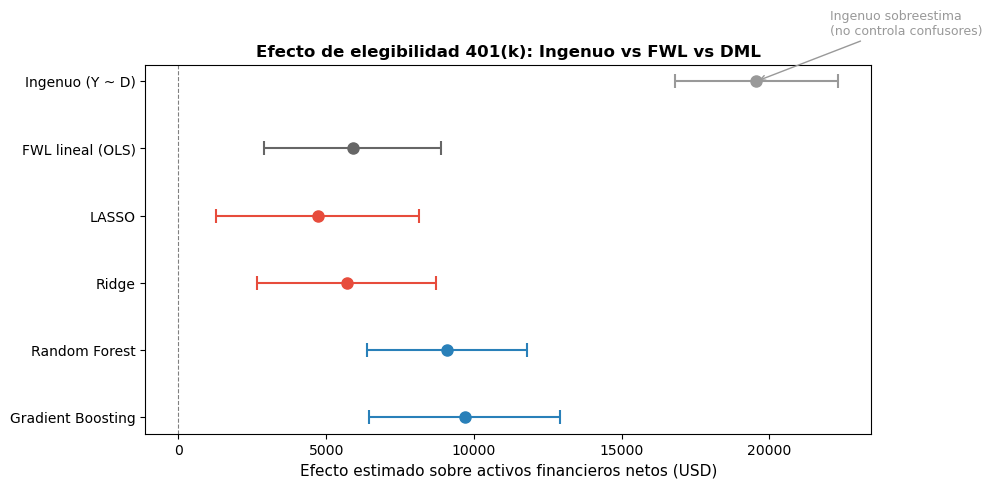

In [8]:

# Grafico: comparacion de estimaciones e intervalos de confianza

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#999999', '#666666', '#e74c3c', '#e74c3c', '#2980b9', '#2980b9']
labels_short = df_res['Metodo'].tolist()

y_pos = np.arange(len(df_res))[::-1]

for i, (_, row) in enumerate(df_res.iterrows()):
    color = colors[i] if i < len(colors) else '#2980b9'
    ax.errorbar(row['beta'], y_pos[i],
                xerr=1.96 * row['SE'],
                fmt='o', color=color, markersize=8,
                capsize=5, capthick=1.5, linewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_short, fontsize=10)
ax.axvline(x=0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Efecto estimado sobre activos financieros netos (USD)', fontsize=11)
ax.set_title('Efecto de elegibilidad 401(k): Ingenuo vs FWL vs DML', fontsize=12, fontweight='bold')

# Anotacion
ax.annotate('Ingenuo sobreestima\n(no controla confusores)',
            xy=(df_res.iloc[0]['beta'], y_pos[0]),
            xytext=(df_res.iloc[0]['beta'] + 2500, y_pos[0] + 0.7),
            fontsize=9, color='#999999',
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1))

plt.tight_layout()
plt.show()

**Resumen de los resultados:**

**1. Ingenuo (~\$19.500):** sobreestima masivamente el efecto. Los hogares elegibles son más ricos, con mayor educación y mayores ingresos — la correlación captura diferencias preexistentes, no solo el efecto del plan.

**2. FWL lineal (~\$5.900):** controlar por observables reduce la estimación en ~70%. Pero asume que la relación entre controles y outcome es lineal ($g(X) = X'\gamma$).

**3. DML con métodos lineales (LASSO ~\$4.700, Ridge ~\$5.800):** similares al FWL lineal — esperado, porque los learners son lineales. La diferencia viene del cross-fitting.

**4. DML con métodos no lineales (RF ~\$9.100, GB ~\$9.500):** estimaciones **más altas** que FWL lineal. ¿Por qué?

La interpretación es que los controles lineales **no capturan toda la confusión**. Random Forest y Gradient Boosting capturan interacciones y no linealidades que el modelo lineal no puede. Cuando removemos *toda* la confusión no lineal, el efecto residual de la elegibilidad es mayor — los métodos lineales estaban absorbiendo parte del efecto de $D$ en la corrección por $X$.

**Mensaje clave:** la elección del learner importa. Los resultados con los mejores predictores de las funciones nuisance (menores RMSE) son los más confiables. En este caso, los árboles dominan a los métodos lineales en predicción, y la estimación causal cambia sustancialmente.

---

## **Parte 3: DML con Variables Instrumentales (LATE)**

### **8. Cuando el tratamiento es endógeno: de 2SLS a DML-IV**

Hasta ahora estimamos el efecto de la **elegibilidad** ($D$ = `e401`) sobre los activos. Pero la pregunta real es: ¿cuál es el efecto de **participar** en 401(k) ($D$ = `p401`)?

**El problema:** la participación es endógena. Los hogares que participan son los más propensos a ahorrar — tienen más ingreso disponible, más conciencia financiera, etc. Controlar por observables no basta.

### **2SLS: la solución econométrica clásica**

En econometría, el método estándar para tratamientos endógenos es **2SLS (Two-Stage Least Squares)**. El procedimiento con un instrumento $Z$ (elegibilidad) para el tratamiento $D$ (participación) es:

**Etapa 1 (forma reducida):** regresar $D$ sobre $X$ y $Z$ por OLS:
$$D = X'\gamma + Z\pi + \nu$$

**Etapa 2:** reemplazar $D$ por $\hat{D}$ y regresar:
$$Y = \hat{D}\beta + X'\delta + \varepsilon$$

**Equivalentemente** (por FWL), 2SLS se puede escribir como un estimador de Wald con residuos:

$$\hat{\beta}_{2SLS} = \frac{\sum_i \tilde{Z}_i \tilde{Y}_i}{\sum_i \tilde{Z}_i \tilde{D}_i}$$

donde $\tilde{Y}$, $\tilde{D}$, $\tilde{Z}$ son residuos de regresar cada variable sobre $X$ por OLS. Esta es exactamente la lógica de partialling out.

### **De 2SLS a DML-IV: la extensión**

**DML-IV** generaliza 2SLS de la misma manera que DML generaliza FWL:

| | **2SLS** | **DML-IV** |
|---|---|---|
| Primera etapa | OLS: $\hat{D} = X'\hat{\gamma} + Z\hat{\pi}$ | ML: $\hat{D} = \hat{h}(X, Z)$ |
| Función de control | Lineal: $g(X) = X'\delta$ | No lineal: $g(X)$ estimada con ML |
| Cross-fitting | No | Sí — evita overfitting |
| Ortogonalidad | Automática por linealidad | Construida explícitamente (Neyman) |
| Supuestos sobre $g(X)$ | Lineal | Cualquier función suave |
| Inferencia | Estándar (bajo homocedasticidad) | Robusta (CLT + ortogonalidad) |

**¿Cuándo DML-IV mejora sobre 2SLS?** Cuando los confusores entran de forma no lineal en las ecuaciones de $Y$ y $D$. Si la primera etapa es realmente lineal, 2SLS y DML-IV dan resultados similares. Si hay no linealidades, 2SLS tiene sesgo por mala especificación.

**Supuestos IV (comunes a 2SLS y DML-IV):**
1. **Relevancia:** $\mathbb{E}[D \mid Z=1, X] \neq \mathbb{E}[D \mid Z=0, X]$ — la elegibilidad afecta la participación.
2. **Exclusión:** $Z$ afecta $Y$ **solo** a través de $D$ — la elegibilidad no afecta directamente el ahorro por otra vía.
3. **Exogeneidad:** $Z \perp (Y(0), Y(1), D(0), D(1)) \mid X$ — la elegibilidad es "cuasi-aleatoria" condicional en $X$.
4. **Monotonicidad:** $D(1) \geq D(0)$ — no hay "desafiadores" (nadie deja de participar *porque* es elegible).

**LATE (Local Average Treatment Effect):** tanto 2SLS como DML-IV identifican el efecto para los **compliadores** — hogares que participarían si fueran elegibles pero no participarían si no lo fueran. LATE $\neq$ ATE en general.

In [9]:

# DML con Variables Instrumentales (IIVM)
# Instrumento: elegibilidad (e401) -> Tratamiento: participacion (p401)

df_iv = data_401k.data.copy()

# Configurar datos para DML-IV
data_iivm = dml.DoubleMLData(
    df_iv,
    y_col='net_tfa',          # Y: activos financieros netos
    d_cols='p401',            # D: participacion (endogena)
    x_cols=x_cols,            # X: controles
    z_cols='e401'             # Z: elegibilidad (instrumento)
)

print(f'DML con Variables Instrumentales')
print(f'  Y: {data_iivm.y_col} (activos netos)')
print(f'  D: {data_iivm.d_cols} (participacion -- endogena)')
print(f'  Z: {data_iivm.z_cols} (elegibilidad -- instrumento)')
print(f'  X: {data_iivm.x_cols}')
print(f'  n: {data_iivm.n_obs:,}')

# Definir learners para las tres funciones nuisance
ml_g = RandomForestRegressor(n_estimators=200, max_depth=7,
                              min_samples_leaf=5, random_state=42)  # E[Y|X]
ml_m = RandomForestClassifier(n_estimators=200, max_depth=7,
                               min_samples_leaf=5, random_state=42)  # P(Z=1|X)
ml_r = RandomForestClassifier(n_estimators=200, max_depth=7,
                               min_samples_leaf=5, random_state=42)  # P(D=1|X)

# Ajustar modelo IIVM (Interactive IV Model)
dml_iv = dml.DoubleMLIIVM(data_iivm, ml_g, ml_m, ml_r,
                           n_folds=5, n_rep=1)
dml_iv.fit()

coef_iv = dml_iv.coef[0]
se_iv = dml_iv.se[0]

print(f'\n  Resultado DML-IV (LATE):')
print(f'  beta_hat = {coef_iv:,.0f} USD')
print(f'  SE       = {se_iv:,.0f}')
print(f'  IC 95%   = [{coef_iv - 1.96*se_iv:,.0f}, {coef_iv + 1.96*se_iv:,.0f}]')
print(f'  t-stat   = {coef_iv/se_iv:.2f}')

DML con Variables Instrumentales
  Y: net_tfa (activos netos)
  D: ['p401'] (participacion -- endogena)
  Z: ['e401'] (elegibilidad -- instrumento)
  X: ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']
  n: 9,915

  Resultado DML-IV (LATE):
  beta_hat = 11,128 USD
  SE       = 1,636
  IC 95%   = [7,922, 14,334]
  t-stat   = 6.80


In [10]:
# 2SLS CLASICO para comparacion con DML-IV

# Usamos la misma especificacion: Y=net_tfa, D=p401, Z=e401, X=controles

Y_iv = df['net_tfa'].values
D_iv = df['p401'].values
Z_iv = df['e401'].values
X_iv = df[x_cols].values

# ------ Etapa 1: D sobre X y Z ------
X_z = sm.add_constant(np.column_stack([X_iv, Z_iv]))
stage1 = sm.OLS(D_iv, X_z).fit()
D_hat = stage1.predict(X_z)

# Test de instrumento debil (Staiger-Stock: F > 10)
f_stat_iv = stage1.tvalues[-1]**2

# ------ Etapa 2: Y sobre D_hat y X ------
X_dhat = sm.add_constant(np.column_stack([D_hat, X_iv]))
stage2 = sm.OLS(Y_iv, X_dhat).fit()

# Corregir errores estandar: usar D real (no D_hat) para calcular residuos
resid_2sls = Y_iv - sm.add_constant(np.column_stack([D_iv, X_iv])) @ stage2.params
n_iv = len(Y_iv)
k_iv = X_dhat.shape[1]
s2_2sls = np.sum(resid_2sls**2) / (n_iv - k_iv)
var_2sls = s2_2sls * np.linalg.inv(X_dhat.T @ X_dhat)
se_2sls = np.sqrt(np.diag(var_2sls))[1]
beta_2sls = stage2.params[1]

# ------ Estimador de Wald simple (sin controles) ------
wald = (Y_iv[Z_iv==1].mean() - Y_iv[Z_iv==0].mean()) / \
       (D_iv[Z_iv==1].mean() - D_iv[Z_iv==0].mean())

print('COMPARACION: METODOS IV CLASICOS vs DML-IV')

print(f'\n  DIAGNOSTICO DEL INSTRUMENTO:')
print(f'  First-stage F-stat: {f_stat_iv:,.0f}  (regla Staiger-Stock: F > 10)')
print(f'  Coef de e401 en ecuacion de p401: {stage1.params[-1]:.4f}')
print(f'  => {stage1.params[-1]*100:.1f}% de los elegibles participan (compliance rate)')

print(f'\n  {"Metodo":<30} {"beta (USD)":>12} {"SE":>10} {"IC 95%":>28}')

print(f'  {"Wald simple (sin controles)":<30}')
print(f'  {"2SLS clasico (lineal)":<30} {beta_2sls:>12,.0f} {se_2sls:>10,.0f}'
      f'  [{beta_2sls-1.96*se_2sls:>10,.0f}, {beta_2sls+1.96*se_2sls:>10,.0f}]')
print(f'  {"DML-IV (Random Forest)":<30} {coef_iv:>12,.0f} {se_iv:>10,.0f}'
      f'  [{coef_iv-1.96*se_iv:>10,.0f}, {coef_iv+1.96*se_iv:>10,.0f}]')

print(f'\n  Diferencia 2SLS vs DML-IV: {abs(beta_2sls - coef_iv):,.0f} USD')
print(f'  => DML-IV estima un efecto {"mayor" if coef_iv > beta_2sls else "menor"} que 2SLS')
print(f'     porque Random Forest captura no linealidades en la primera etapa')
print(f'     que 2SLS lineal no puede modelar.')

COMPARACION: METODOS IV CLASICOS vs DML-IV

  DIAGNOSTICO DEL INSTRUMENTO:
  First-stage F-stat: 12,595  (regla Staiger-Stock: F > 10)
  Coef de e401 en ecuacion de p401: 0.6935
  => 69.3% de los elegibles participan (compliance rate)

  Metodo                           beta (USD)         SE                       IC 95%
  Wald simple (sin controles)   
  2SLS clasico (lineal)                 8,502      1,798  [     4,978,     12,027]
  DML-IV (Random Forest)               11,128      1,636  [     7,922,     14,334]

  Diferencia 2SLS vs DML-IV: 2,626 USD
  => DML-IV estima un efecto mayor que 2SLS
     porque Random Forest captura no linealidades en la primera etapa
     que 2SLS lineal no puede modelar.


**Interpretación de la comparación 2SLS vs DML-IV:**

**Wald simple (~\$27.800):** divide la diferencia bruta en outcomes por la diferencia en participación. No controla por nada — equivalente a IV sin controles. Fuertemente sesgado.

**2SLS clásico (~\$8.500):** controla por observables, pero asume que la relación entre controles y outcomes/participación es lineal. Es lo que obtendrían en Stata con:

```stata
ivregress 2sls net_tfa age inc educ fsize marr twoearn db pira hown (p401 = e401), robust
```

**DML-IV (~\$11.100):** usa Random Forest para modelar las funciones nuisance de forma no lineal. La diferencia con 2SLS indica que hay **interacciones y no linealidades** en cómo los controles afectan la participación y los activos — por ejemplo, el efecto del ingreso sobre la participación probablemente no es lineal (hay un umbral por debajo del cual nadie participa, y rendimientos marginales decrecientes arriba).

**¿Cuándo confiar en cada método?** Si creen que el modelo lineal es una buena aproximación de la primera etapa, 2SLS es eficiente y parsimonioso. Si sospechan no linealidades en los controles (frecuente con datos de encuestas donde hay interacciones complejas entre ingreso, edad, educación y decisiones de ahorro), DML-IV es más robusto.

**Resumen comparativo de todas las estrategias:**

| Estrategia | $\hat{\beta}$ (USD) | Interpretación | Análogo en Stata |
|---|---|---|---|
| **Ingenuo** ($Y \sim D$) | ~\$19.500 | Sesgo de selección masivo | `reg net_tfa e401` |
| **FWL lineal** (OLS partialling out) | ~\$5.900 | Controla confusores linealmente — ITT | `reg net_tfa e401 age inc ...` |
| **DML-PLR** (RF, $D$ = elegibilidad) | ~\$9.000 | Controla confusores no linealmente — ITT | Sin análogo directo |
| **Wald simple** (IV sin controles) | ~\$27.800 | IV sin controles — sesgado | `ivregress 2sls net_tfa (p401=e401)` |
| **2SLS clásico** | ~\$8.500 | IV con controles lineales — LATE | `ivregress 2sls net_tfa X (p401=e401)` |
| **DML-IV** (RF) | ~\$11.100 | IV con controles no lineales — LATE | Sin análogo directo |

**¿Por qué LATE > ITT?** El efecto ITT (intention-to-treat, DML-PLR) es el efecto de ser **elegible**, que incluye a hogares elegibles que no participan. El LATE escala el efecto por la tasa de compliance — divide por la fracción que efectivamente cambia su comportamiento cuando se le ofrece el plan. Como no todos los elegibles participan, $\text{LATE} > \text{ITT}$ es consistente con la teoría.

**¿Por qué DML-IV > 2SLS?** Ambos estiman LATE, pero DML-IV captura mejor la confusión no lineal en la primera etapa. 2SLS con primera etapa mal especificada tiene sesgo residual por las no linealidades que el modelo lineal no captura.

**Advertencia:** LATE $\neq$ ATE. El LATE aplica solo a los compliadores — hogares que cambian su participación en respuesta a la elegibilidad. Si los compliadores son hogares con ingreso medio que responden a incentivos tributarios, el efecto para la población general podría ser diferente.

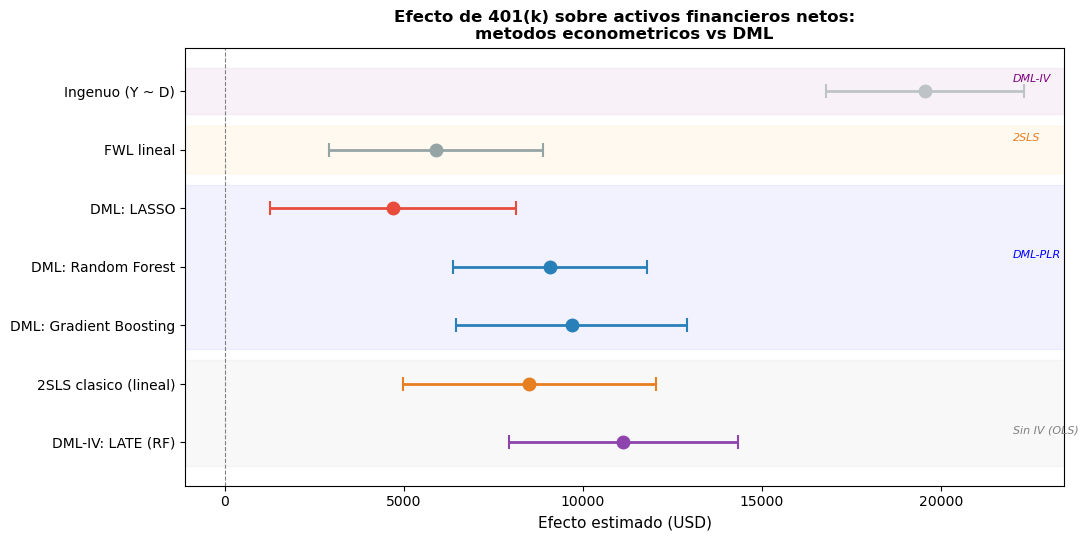

In [11]:

# Grafico final: todas las estimaciones (incluyendo 2SLS)

all_results = [
    ('Ingenuo (Y ~ D)',          naive_ols.params[1], naive_ols.bse[1]),
    ('FWL lineal',               fwl_ols.params[1],   fwl_ols.bse[1]),
    ('DML: LASSO',               df_res.iloc[2]['beta'], df_res.iloc[2]['SE']),
    ('DML: Random Forest',       df_res.iloc[4]['beta'], df_res.iloc[4]['SE']),
    ('DML: Gradient Boosting',   df_res.iloc[5]['beta'], df_res.iloc[5]['SE']),
    ('2SLS clasico (lineal)',    beta_2sls, se_2sls),
    ('DML-IV: LATE (RF)',        coef_iv, se_iv),
]

fig, ax = plt.subplots(figsize=(11, 5.5))

# Colores: gris=ingenuo/lineal, rojo=DML-lineal, azul=DML-nolineal, naranja=2SLS, morado=DML-IV
colors = ['#bdc3c7', '#95a5a6', '#e74c3c', '#2980b9', '#2980b9', '#e67e22', '#8e44ad']
y_pos = np.arange(len(all_results))[::-1]

for i, (name, beta, se) in enumerate(all_results):
    ax.errorbar(beta, y_pos[i], xerr=1.96 * se,
                fmt='o', color=colors[i], markersize=9,
                capsize=5, capthick=1.5, linewidth=2)

ax.set_yticks(y_pos)
ax.set_yticklabels([r[0] for r in all_results], fontsize=10)
ax.axvline(x=0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Efecto estimado (USD)', fontsize=11)
ax.set_title('Efecto de 401(k) sobre activos financieros netos:\nmetodos econometricos vs DML',
             fontsize=12, fontweight='bold')

# Regiones con etiquetas
ax.axhspan(y_pos[-1] - 0.4, y_pos[-2] + 0.4, alpha=0.05, color='grey')
ax.axhspan(y_pos[-3] - 0.4, y_pos[-5] + 0.4, alpha=0.05, color='blue')
ax.axhspan(y_pos[-6] - 0.4, y_pos[-6] + 0.4, alpha=0.06, color='orange')
ax.axhspan(y_pos[-7] - 0.4, y_pos[-7] + 0.4, alpha=0.05, color='purple')

ax.text(22000, y_pos[-1] + 0.15, 'Sin IV (OLS)', fontsize=8, color='grey', fontstyle='italic')
ax.text(22000, y_pos[-4] + 0.15, 'DML-PLR', fontsize=8, color='blue', fontstyle='italic')
ax.text(22000, y_pos[-6] + 0.15, '2SLS', fontsize=8, color='#e67e22', fontstyle='italic')
ax.text(22000, y_pos[-7] + 0.15, 'DML-IV', fontsize=8, color='purple', fontstyle='italic')

plt.tight_layout()
plt.show()

---

### **RESUMEN**

**Parte 1 — Frisch-Waugh-Lovell**

- El teorema FWL dice que el coeficiente de $D$ en una regresión múltiple es **numéricamente idéntico** al de regresar los residuos de $Y$ sobre los residuos de $D$, ambos limpiados de la influencia de los controles.
- FWL es la base teórica de OLS multivariado, **2SLS**, control function y DML. Todos operan sobre la misma lógica: **aislar la variación limpia** en $D$ que no se explica por $X$.

**Parte 2 — Double Machine Learning**

- DML generaliza FWL reemplazando las proyecciones lineales por ML — modela $\ell(X) = \mathbb{E}[Y \mid X]$ y $m(X) = \mathbb{E}[D \mid X]$ de forma flexible.
- Dos ingredientes son necesarios para que la inferencia sea válida: **ortogonalidad de Neyman** (el sesgo de ML se multiplica en vez de sumarse) y **cross-fitting** (evitar overfitting).
- En la aplicación 401(k), los métodos no lineales (RF, GB) producen estimaciones sustancialmente diferentes a los lineales (~\$9.000 vs ~\$5.000), indicando que la confusión no lineal es relevante.

**Parte 3 — DML con IV vs 2SLS**

- **2SLS** es el análogo lineal clásico: primera etapa OLS, segunda etapa OLS. Asume que $g(X) = X'\gamma$ y $h(Z, X) = X'\delta + Z\pi$.
- **DML-IV** reemplaza ambas etapas por ML con cross-fitting. Mantiene los mismos supuestos de identificación (relevancia, exclusión, exogeneidad, monotonicidad) pero relaja la forma funcional.
- En la aplicación 401(k): 2SLS estima ~\$8.500, DML-IV estima ~\$11.100 — la diferencia refleja la confusión no lineal que 2SLS no captura.
- Ambos identifican **LATE** (efecto para compliadores), no ATE.

**El pipeline completo:**

$$\underbrace{\text{OLS}}_{\text{Ay. 1-3}} \xrightarrow{\text{FWL}} \underbrace{\text{2SLS}}_{\text{Econometría}} \xrightarrow{\text{ML + ortogonalidad + cross-fitting}} \underbrace{\text{DML / DML-IV}}_{\text{Hoy}}$$

---

##### *Referencias*

**Papers:**
- Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018). "Double/debiased machine learning for treatment and structural parameters." *The Econometrics Journal, 21*(1), C1–C68.
- Belloni, A., Chernozhukov, V., & Hansen, C. (2014). "High-dimensional methods and inference on structural and treatment effects." *Journal of Economic Perspectives, 28*(2), 29–50.
- Frisch, R. & Waugh, F. V. (1933). "Partial time regressions as compared with individual trends." *Econometrica, 1*(4), 387–401.

**Paquete:**
- Bach, P., Chernozhukov, V., Kurz, M. S., & Spindler, M. (2022). "DoubleML — an object-oriented implementation of double machine learning in Python." *Journal of Machine Learning Research, 23*(53), 1–6. [Documentación](https://docs.doubleml.org/)

**Datos:**
- 401(k): Chernozhukov & Hansen (2004), basado en SIPP (Survey of Income and Program Participation).
- Armas de fuego: Chernozhukov et al. (2018), datos del curso EAE3709.

---

### **¿Cómo aplicar esto en la práctica?**

El paquete `doubleml` implementa los modelos principales:

| Clase | Modelo | Uso |
|---|---|---|
| `DoubleMLPLR` | Partially Linear Regression | Efecto de $D$ continuo o binario, controles no lineales |
| `DoubleMLIRM` | Interactive Regression Model | Tratamiento binario, heterogeneidad en el efecto |
| `DoubleMLIIVM` | Interactive IV Model | Tratamiento endógeno con instrumento binario |
| `DoubleMLPLIV` | Partially Linear IV | IV con tratamiento continuo |

**Recomendaciones:**

1. **Empezar con Random Forest o Gradient Boosting** — son robustos y suelen funcionar bien como learners.
2. **Comparar siempre múltiples learners** — si los resultados cambian mucho, puede indicar misspecification o violación de supuestos.
3. **Usar `n_folds=5`** como default. Para muestras pequeñas, `n_folds=2` puede bastar.
4. **Nunca olvidar el cross-fitting** — sin él, la inferencia no es válida, incluso con ortogonalidad.
5. **Identificación primero, estimación después** — DML no resuelve problemas de identificación. Si los supuestos de exogeneidad condicional no se cumplen, la estimación sigue siendo inconsistente.

# *Anexo: Variables Instrumentales y 2SLS

La idea de esta sección es entregar una explicación básica sobre **variables instrumentales (IV)** y **Two-Stage Least Squares (2SLS)** considerando: definiciones formales, supuestos de identificación, derivaciones completas, propiedades asintóticas, diagnósticos y ejemplos numéricos. El objetivo es que sirva como puente entre la econometría y el DML-IV que vimos en la ayudantía.

---

## **1. El problema de endogeneidad**

### **1.1 El modelo estructural**

Consideremos el modelo lineal:

$$Y_i = \beta D_i + X_i'\gamma + \varepsilon_i, \quad i = 1, \ldots, n \tag{1}$$

donde:
- $Y_i$ es el outcome (e.g., salarios),
- $D_i$ es el regresor de interés (e.g., años de educación),
- $X_i$ es un vector $p \times 1$ de controles exógenos, y
- $\varepsilon_i$ es el error estructural.

**Supuesto clave de OLS:** $\mathbb{E}[\varepsilon_i \mid D_i, X_i] = 0$, lo que implica $\text{Cov}(D_i, \varepsilon_i) = 0$. Bajo este supuesto, OLS es insesgado y consistente para $\beta$.

### **1.2 ¿Qué es endogeneidad?**

Decimos que $D_i$ es **endógeno** cuando:

$$\text{Cov}(D_i, \varepsilon_i) \neq 0 \tag{2}$$

Esto viola el supuesto de exogeneidad de OLS y genera **sesgo e inconsistencia** en $\hat{\beta}^{OLS}$: ni siquiera con $n \to \infty$ el estimador converge al parámetro verdadero.

**Fuentes de endogeneidad:**

| Fuente | Mecanismo | Ejemplo |
|---|---|---|
| **Variable omitida** | $\varepsilon_i$ contiene una variable que afecta tanto $D_i$ como $Y_i$ | Habilidad no observada afecta educación y salarios |
| **Simultaneidad** | $D_i$ causa $Y_i$ y $Y_i$ causa $D_i$ | Precio y cantidad en un mercado |
| **Error de medición** | $D_i^* = D_i + u_i$, el error $u_i$ se transmite a $\varepsilon_i$ | Ingreso autodeclarado con error |
| **Autoselección** | Los individuos eligen $D_i$ en función de su $\varepsilon_i$ | Quienes más se beneficiarían de un programa son los que participan |

### **1.3 Dirección y magnitud del sesgo de OLS**

En el caso de variable omitida, si $A_i$ es la variable omitida (e.g., habilidad):

$$Y_i = \beta D_i + \delta A_i + X_i'\gamma + u_i$$

y $D_i = \pi A_i + X_i'\phi + \nu_i$, entonces el sesgo de OLS (omitiendo $A_i$) es:

$$\text{plim}(\hat{\beta}^{OLS}) - \beta = \delta \cdot \frac{\text{Cov}(D_i, A_i \mid X_i)}{\text{Var}(D_i \mid X_i)} \tag{3}$$

El sesgo es el producto del efecto de la omitida sobre $Y$ ($\delta$) por la "regresión auxiliar" de la omitida sobre $D$ ($\text{Cov}(D, A)/\text{Var}(D)$). Si ambos son positivos (habilidad aumenta salarios y aumenta educación), el sesgo es **positivo**: OLS **sobreestima** el retorno a la educación.

---

## **2. Variables instrumentales: definición y supuestos**

### **2.1 Definición**

Una variable $Z_i$ es un **instrumento válido** para $D_i$ en el modelo (1) si satisface tres condiciones:

**Condición 1 — Relevancia (first stage):**

$$\text{Cov}(Z_i, D_i \mid X_i) \neq 0 \tag{R}$$

El instrumento está correlacionado con el tratamiento, condicional en los controles. $Z_i$ tiene poder predictivo sobre $D_i$ más allá del que ya aportan los controles $X_i$.

**Condición 2 — Exogeneidad (exclusion restriction):**

$$\text{Cov}(Z_i, \varepsilon_i \mid X_i) = 0 \tag{E}$$

El instrumento no está correlacionado con el error estructural. $Z_i$ no tiene un efecto directo sobre $Y_i$ — afecta $Y_i$ **solo a través de** $D_i$.

**Condición 3 — Restricción de exclusión (en versión causal/LATE):**

$$Z_i \perp \!\!\! \perp \big(Y_i(0), Y_i(1), D_i(0), D_i(1)\big) \mid X_i$$

El instrumento es "como si fuera aleatorio" condicional en $X_i$. Es independiente de los outcomes potenciales y de las decisiones de tratamiento potenciales.

### **2.2 Diagrama causal**

La estructura causal requerida es:

$$Z \longrightarrow D \longrightarrow Y$$

con la restricción de que **no existe** flecha directa $Z \longrightarrow Y$ (exclusión) ni una variable no observada $U$ tal que $Z \leftarrow U \rightarrow Y$ (exogeneidad).

En presencia de controles $X$:

$$Z \longrightarrow D \longrightarrow Y \longleftarrow X$$

y $X$ puede afectar tanto $Z$ como $D$ como $Y$, siempre que condicional en $X$, la exclusión y exogeneidad de $Z$ se mantengan.

### **2.3 Ejemplos clásicos de instrumentos en economía**

| Pregunta causal | $D$ (endógeno) | $Z$ (instrumento) | Referencia |
|---|---|---|---|
| Retorno a la educación | Años de educación | Trimestre de nacimiento | Angrist & Krueger (1991) |
| Efecto de 401(k) sobre ahorro | Participación en 401(k) | Elegibilidad 401(k) | Chernozhukov & Hansen (2004) |
| Efecto de instituciones sobre desarrollo | Calidad institucional | Mortalidad de colonizadores | Acemoglu, Johnson & Robinson (2001) |
| Efecto del tamaño de la familia sobre empleo materno | Número de hijos | Sexo de los dos primeros hijos (mismo sexo) | Angrist & Evans (1998) |
| Efecto de inmigración sobre salarios nativos | Flujo de inmigrantes | Distancia geográfica / shift-share | Card (2001) |

### **2.4 ¿Qué hace que un instrumento sea "bueno"?**

Los dos supuestos (relevancia y exclusión) tienen naturalezas muy diferentes:

- **Relevancia** es **testeable**: se puede verificar empíricamente con el F-test de la primera etapa. Si $F < 10$ (regla de Staiger & Stock, 1997), el instrumento es "débil" y el estimador IV tiene mal comportamiento en muestras finitas.

- **Exclusión/exogeneidad** es **no testeable** (en el caso exactamente identificado, con un solo instrumento): es un supuesto de identificación que debe justificarse teóricamente. Solo con sobreidentificación ($\#$ instrumentos $>$ $\#$ endógenas) se puede hacer un test parcial (Hansen J-test / Sargan test), pero este test es de validez conjunta, no individual.

---

## **3. El estimador de Wald: el caso más simple**

### **3.1 Setup**

Consideremos el caso más simple: **sin controles** ($X = \emptyset$), con un **instrumento binario** $Z_i \in \{0, 1\}$ y un **tratamiento binario** $D_i \in \{0, 1\}$:

$$Y_i = \beta D_i + \varepsilon_i, \quad \text{Cov}(D_i, \varepsilon_i) \neq 0, \quad \text{Cov}(Z_i, \varepsilon_i) = 0$$

### **3.2 Derivación**

La condición de momentos poblacional de IV es:

$$\mathbb{E}[Z_i(Y_i - \beta D_i)] = 0 \tag{4}$$

que se obtiene de multiplicar la ecuación estructural por $Z_i$ y tomar esperanzas, usando $\mathbb{E}[Z_i \varepsilon_i] = 0$.

Expandiendo:

$$\mathbb{E}[Z_i Y_i] - \beta \mathbb{E}[Z_i D_i] = 0$$

Despejando:

$$\beta = \frac{\mathbb{E}[Z_i Y_i]}{\mathbb{E}[Z_i D_i]} \tag{5}$$

Restando $\mathbb{E}[Z_i]\mathbb{E}[Y_i]$ del numerador y $\mathbb{E}[Z_i]\mathbb{E}[D_i]$ del denominador (lo que no cambia el cociente cuando centramos por la ley de covarianza):

$$\beta = \frac{\text{Cov}(Z_i, Y_i)}{\text{Cov}(Z_i, D_i)} \tag{6}$$

El análogo muestral (método de momentos) es el **estimador de Wald:**

$$\hat{\beta}^{Wald} = \frac{\widehat{\text{Cov}}(Z_i, Y_i)}{\widehat{\text{Cov}}(Z_i, D_i)} \tag{7}$$

Con $Z_i$ binario, esto se simplifica a:

$$\boxed{\hat{\beta}^{Wald} = \frac{\bar{Y}_{Z=1} - \bar{Y}_{Z=0}}{\bar{D}_{Z=1} - \bar{D}_{Z=0}}} \tag{8}$$

### **3.3 Interpretación como razón de formas reducidas**

El numerador $\bar{Y}_{Z=1} - \bar{Y}_{Z=0}$ es el efecto de $Z$ sobre $Y$ (la **forma reducida** o **ITT** — intention-to-treat). El denominador $\bar{D}_{Z=1} - \bar{D}_{Z=0}$ es el efecto de $Z$ sobre $D$ (la **primera etapa** o **compliance rate**).

El estimador de Wald **escala** el efecto reducido por la tasa de compliance:

$$\hat{\beta}^{Wald} = \frac{\text{ITT}}{\text{Primera etapa}} = \frac{\text{Efecto de } Z \text{ sobre } Y}{\text{Efecto de } Z \text{ sobre } D}$$

### **3.4 Interpretación LATE (Imbens & Angrist, 1994)**

Con tratamiento binario e instrumento binario, bajo los supuestos de IV más **monotonicidad** ($D_i(1) \geq D_i(0)$ para todo $i$ — no hay "desafiadores"), el estimador de Wald identifica el **LATE (Local Average Treatment Effect):**

$$\beta^{LATE} = \mathbb{E}[Y_i(1) - Y_i(0) \mid D_i(1) > D_i(0)] \tag{9}$$

Es decir, el efecto causal promedio para los **compliadores** — individuos que cambian su tratamiento en respuesta al instrumento. Esto es una subpoblación, no toda la población.

**Tipos de individuos (Angrist, Imbens & Rubin, 1996):**

| Tipo | Definición | Ejemplo 401(k) |
|---|---|---|
| **Compliadores** | $D(1) = 1, D(0) = 0$ | Participan si son elegibles, no participan si no lo son |
| **Always-takers** | $D(1) = 1, D(0) = 1$ | Participarían de todas formas (e.g., ahorran por su cuenta) |
| **Never-takers** | $D(1) = 0, D(0) = 0$ | No participarían aunque fueran elegibles |
| **Desafiadores** | $D(1) = 0, D(0) = 1$ | Excluidos por monotonicidad |

El LATE solo captura el efecto para los compliadores. Si $\text{LATE} \neq \text{ATE}$, hay **heterogeneidad** en el efecto del tratamiento.

---

## **4. Two-Stage Least Squares (2SLS): derivación formal**

### **4.1 Setup general**

Modelo estructural con controles:

$$Y_i = \beta D_i + X_i'\gamma + \varepsilon_i, \quad \mathbb{E}[\varepsilon_i \mid X_i, Z_i] = 0, \quad \text{Cov}(D_i, \varepsilon_i) \neq 0 \tag{10}$$

donde $Z_i$ es un vector de instrumentos (puede haber más de uno). Definimos:
- $W_i = (D_i, X_i')' \in \mathbb{R}^{k}$: todos los regresores del modelo estructural,
- $\tilde{Z}_i = (Z_i, X_i')' \in \mathbb{R}^{l}$: todos los instrumentos (excluidos + incluidos), con $l \geq k$.

Los controles $X_i$ se incluyen en ambos conjuntos porque son sus propios instrumentos (son exógenos).

### **4.2 Las dos etapas**

**Etapa 1 — Primera etapa (reduced form for $D$).**

Regresar la variable endógena $D_i$ sobre **todos** los instrumentos y controles:

$$D_i = Z_i'\pi + X_i'\phi + \nu_i \tag{11}$$

por OLS. Obtener los valores ajustados:

$$\hat{D}_i = Z_i'\hat{\pi} + X_i'\hat{\phi} = \tilde{Z}_i'\hat{\delta}_1$$

donde $\hat{\delta}_1 = (\tilde{Z}'\tilde{Z})^{-1}\tilde{Z}'D$ es el vector de coeficientes de la primera etapa.

**Etapa 2 — Segunda etapa.**

Regresar $Y_i$ sobre los valores ajustados $\hat{D}_i$ y los controles $X_i$:

$$Y_i = \beta \hat{D}_i + X_i'\gamma + \text{error} \tag{12}$$

por OLS. El coeficiente de $\hat{D}_i$ es $\hat{\beta}^{2SLS}$.

### **4.3 Derivación matricial**

En notación matricial, el estimador 2SLS es:

$$\hat{\theta}^{2SLS} = (\hat{W}'\hat{W})^{-1}\hat{W}'Y \tag{13}$$

donde $\hat{W} = P_{\tilde{Z}} W$ es la proyección de $W$ sobre el espacio generado por los instrumentos, y $P_{\tilde{Z}} = \tilde{Z}(\tilde{Z}'\tilde{Z})^{-1}\tilde{Z}'$ es la matriz de proyección.

**Equivalentemente**, sustituyendo $P_{\tilde{Z}}$:

$$\hat{\theta}^{2SLS} = \left(W' P_{\tilde{Z}} W\right)^{-1} W' P_{\tilde{Z}} Y \tag{14}$$

Esta es la **fórmula general de 2SLS** (o IV generalizado). Es el estimador de GMM con matriz de pesos $P_{\tilde{Z}}$.

### **4.4 Caso exactamente identificado ($l = k$)**

Cuando el número de instrumentos iguala el número de regresores endógenos, $P_{\tilde{Z}}$ es idempotente y (14) se simplifica al **estimador IV clásico**:

$$\hat{\beta}^{IV} = (\tilde{Z}'W)^{-1}\tilde{Z}'Y \tag{15}$$

En el caso escalar (un instrumento, una endógena, sin controles):

$$\hat{\beta}^{IV} = \frac{\sum_i Z_i Y_i}{\sum_i Z_i D_i} = \frac{\widehat{\text{Cov}}(Z, Y)}{\widehat{\text{Cov}}(Z, D)} = \hat{\beta}^{Wald}$$

Recuperamos el estimador de Wald como caso particular.

---

## **5. 2SLS vía Frisch-Waugh-Lovell**

### **5.1 Partialling out en 2SLS**

Una representación alternativa — y muy reveladora — de 2SLS utiliza FWL para remover primero la influencia de los controles $X$. Este es el puente directo hacia DML-IV.

**Paso 1.** Residualizar todas las variables respecto a $X$:

$$\tilde{Y}_i = Y_i - X_i'\hat{\gamma}_Y, \quad \tilde{D}_i = D_i - X_i'\hat{\gamma}_D, \quad \tilde{Z}_i = Z_i - X_i'\hat{\gamma}_Z$$

donde cada $\hat{\gamma}$ es el coeficiente OLS de la regresión auxiliar correspondiente.

**Paso 2.** Aplicar IV en los residuos:

$$\hat{\beta}^{2SLS} = \frac{\sum_i \tilde{Z}_i \tilde{Y}_i}{\sum_i \tilde{Z}_i \tilde{D}_i} \tag{16}$$

### **5.2 Demostración de equivalencia**

Por el teorema de FWL, para cualquier regresión de la forma $Y = W\theta + e$, el coeficiente de un subconjunto de $W$ es igual al coeficiente de regresar los residuos de $Y$ (respecto al otro subconjunto) sobre los residuos de ese subconjunto.

En 2SLS, la segunda etapa es $Y = \beta \hat{D} + X'\gamma + u$. Por FWL, $\hat{\beta}^{2SLS}$ es el coeficiente de regresar $\tilde{Y}$ sobre $\tilde{\hat{D}}$ (los residuos de $\hat{D}$ respecto a $X$).

Pero $\hat{D}$ es una combinación lineal de $Z$ y $X$ (de la primera etapa), así que $\tilde{\hat{D}}$ (el residuo de $\hat{D}$ respecto a $X$) es proporcional a $\tilde{Z}$ (el residuo de $Z$ respecto a $X$). En el caso exactamente identificado:

$$\tilde{\hat{D}}_i = \hat{\pi} \cdot \tilde{Z}_i$$

Sustituyendo en la regresión FWL $\tilde{Y}_i = \beta \cdot \hat{\pi} \tilde{Z}_i + u_i$:

$$\hat{\beta}^{2SLS} = \frac{\sum_i \tilde{Z}_i \tilde{Y}_i}{\hat{\pi} \sum_i \tilde{Z}_i^2} = \frac{\sum_i \tilde{Z}_i \tilde{Y}_i}{\sum_i \tilde{Z}_i \tilde{D}_i}$$

ya que $\hat{\pi} = \sum_i \tilde{Z}_i \tilde{D}_i / \sum_i \tilde{Z}_i^2$ (coeficiente de la primera etapa residualizada). $\blacksquare$

### **5.3 Conexión con DML-IV**

La ecuación (16) revela la estructura de 2SLS:

$$\hat{\beta}^{2SLS} = \frac{\sum_i \tilde{Z}_i \tilde{Y}_i}{\sum_i \tilde{Z}_i \tilde{D}_i}$$

donde las tildes son residuos de regresiones **lineales** de cada variable sobre $X$.

**DML-IV** reemplaza las regresiones lineales por ML:

$$\hat{\beta}^{DML\text{-}IV} = \frac{\sum_i \tilde{Z}_i^{ML} \tilde{Y}_i^{ML}}{\sum_i \tilde{Z}_i^{ML} \tilde{D}_i^{ML}}$$

con $\tilde{Y}_i^{ML} = Y_i - \hat{\ell}_{-k}(X_i)$, $\tilde{D}_i^{ML} = D_i - \hat{r}_{-k}(X_i)$, $\tilde{Z}_i^{ML} = Z_i - \hat{m}_{-k}(X_i)$, donde $\hat{\ell}$, $\hat{r}$, $\hat{m}$ son estimadores ML cross-fitted.

Es exactamente la misma fórmula, con dos diferencias:
1. ML en vez de OLS para las funciones nuisance.
2. Cross-fitting ($-k$) para evitar overfitting.

---

## **6. Propiedades asintóticas de 2SLS**

### **6.1 Consistencia**

Bajo los supuestos de relevancia ($\text{Cov}(Z, D \mid X) \neq 0$) y exogeneidad ($\text{Cov}(Z, \varepsilon \mid X) = 0$):

$$\hat{\beta}^{2SLS} \xrightarrow{p} \beta \tag{17}$$

**Demostración (caso simple, sin controles):**

$$\hat{\beta}^{IV} = \frac{\widehat{\text{Cov}}(Z, Y)}{\widehat{\text{Cov}}(Z, D)} = \frac{\widehat{\text{Cov}}(Z, \beta D + \varepsilon)}{\widehat{\text{Cov}}(Z, D)} = \beta + \frac{\widehat{\text{Cov}}(Z, \varepsilon)}{\widehat{\text{Cov}}(Z, D)}$$

Por la ley de los grandes números:

$$\frac{\widehat{\text{Cov}}(Z, \varepsilon)}{\widehat{\text{Cov}}(Z, D)} \xrightarrow{p} \frac{\text{Cov}(Z, \varepsilon)}{\text{Cov}(Z, D)} = \frac{0}{\text{Cov}(Z, D)} = 0$$

siempre que $\text{Cov}(Z, D) \neq 0$ (relevancia). $\blacksquare$

**Nota:** si $\text{Cov}(Z, D) \approx 0$ (instrumento débil), el denominador es cercano a cero y la convergencia es lenta — el estimador tiene mal comportamiento en muestras finitas (sesgo hacia OLS, distribución no normal).

### **6.2 Distribución asintótica**

Bajo condiciones de regularidad estándar:

$$\sqrt{n}\left(\hat{\beta}^{2SLS} - \beta\right) \xrightarrow{d} \mathcal{N}\left(0, \sigma^2_\varepsilon \left(\text{plim}\frac{1}{n}\hat{W}'\hat{W}\right)^{-1}\right) \tag{18}$$

donde $\sigma^2_\varepsilon = \text{Var}(\varepsilon_i)$ bajo homocedasticidad.

### **6.3 Errores estándar de 2SLS**

**Punto crucial:** los errores estándar de la segunda etapa **no se calculan** con los residuos de la regresión de $Y$ sobre $\hat{D}$. Se deben corregir usando los valores **originales** de $D$ (no $\hat{D}$) para computar los residuos:

$$\hat{\varepsilon}_i^{2SLS} = Y_i - \hat{\beta}^{2SLS} D_i - X_i'\hat{\gamma}^{2SLS} \tag{19}$$

y luego:

$$\widehat{\text{Var}}(\hat{\beta}^{2SLS}) = \hat{\sigma}^2_\varepsilon (\hat{W}'\hat{W})^{-1} \tag{20}$$

con $\hat{\sigma}^2_\varepsilon = \frac{1}{n-k}\sum_i (\hat{\varepsilon}_i^{2SLS})^2$, o su versión robusta a heteroscedasticidad (HC).

**Error común en la práctica:** ejecutar manualmente las dos etapas y tomar los errores estándar de la segunda regresión directamente. Esto produce errores estándar **incorrectos** (generalmente subestimados) porque ignora que $\hat{D}$ es un predictor estimado. Los paquetes estadísticos (`ivregress`, `ivreg`, `linearmodels`) hacen la corrección automáticamente.

---

## **7. Diagnósticos: instrumentos débiles y sobreidentificación**

### **7.1 Test de instrumento débil (Staiger & Stock, 1997)**

**Problema:** si el instrumento es débil ($\text{Cov}(Z, D \mid X) \approx 0$), 2SLS tiene tres patologías:
1. **Sesgo** hacia OLS en muestras finitas (el estimador IV "hereda" el sesgo de OLS).
2. **Distribución no normal** — los intervalos de confianza estándar tienen cobertura incorrecta.
3. **Tamaño distorsionado** de los tests de hipótesis.

**Diagnóstico:** el **F-test de la primera etapa**. Se estima la primera etapa:

$$D_i = Z_i'\pi + X_i'\phi + \nu_i$$

y se reporta el estadístico $F$ del test $H_0: \pi = 0$ (o el $F$ parcial de los instrumentos excluidos).

**Regla de Staiger & Stock (1997):** si $F < 10$, el instrumento es débil y los resultados de 2SLS no son confiables.

**Stock & Yogo (2005)** proveen valores críticos más precisos según el número de instrumentos y el sesgo máximo tolerable.

### **7.2 Test de sobreidentificación (Hansen J-test / Sargan test)**

Cuando hay más instrumentos que regresores endógenos ($l > k$, **sobreidentificación**), se puede testear si los instrumentos adicionales son válidos.

**Hipótesis nula:** $H_0$: todos los instrumentos son exógenos ($\mathbb{E}[Z_i \varepsilon_i] = 0$ para todo instrumento).

**Estadístico J de Hansen:**

$$J = n \cdot \hat{\varepsilon}^{2SLS'} \tilde{Z} \left(\tilde{Z}'\tilde{Z}\right)^{-1} \tilde{Z}' \hat{\varepsilon}^{2SLS} / \hat{\sigma}^2 \xrightarrow{d} \chi^2_{l-k}$$

Si $J$ es grande (p-valor pequeño), rechazamos la hipótesis de que todos los instrumentos son válidos. **Pero:** si rechazamos, no sabemos **cuál** instrumento es inválido.

**Limitación fundamental:** el test de sobreidentificación no puede detectar si **todos** los instrumentos son inválidos de la misma manera (e.g., todos correlacionados con el error en la misma dirección). Solo detecta inconsistencias **entre** instrumentos.

---

## **8. Ejemplo numérico 1: simulación con variable omitida**

Simulamos un DGP con endogeneidad por variable omitida. Verificamos que OLS es sesgado, IV es consistente, y 2SLS produce la corrección exacta.

In [12]:

# Simulacion: retornos a la educacion con habilidad omitida

import numpy as np
import statsmodels.api as sm

np.random.seed(42)
n = 5000
TRUE_BETA = 0.5  # retorno verdadero a la educacion

# --- DGP ---
# Habilidad (no observada): confusor
habilidad = np.random.normal(0, 1, n)

# Instrumento: trimestre de nacimiento (exogeno, afecta educacion
# via leyes de escolaridad obligatoria, no afecta salarios directamente)
Z = np.random.binomial(1, 0.5, n)  # binario para simplicidad

# Educacion (endogena): depende de habilidad Y del instrumento
# pi = 2: el instrumento aumenta la educacion en 2 anhos en promedio
educacion = 12 + 2 * Z + 1.5 * habilidad + np.random.normal(0, 1, n)

# Salarios (outcome): depende de educacion y habilidad
# delta = 3: la habilidad tiene efecto directo sobre salarios
salarios = TRUE_BETA * educacion + 3 * habilidad + np.random.normal(0, 1, n)


# 1. OLS (sesgado por variable omitida)

ols = sm.OLS(salarios, sm.add_constant(educacion)).fit(cov_type='HC1')


# 2. Estimador de Wald (IV sin controles)

wald_num = salarios[Z == 1].mean() - salarios[Z == 0].mean()
wald_den = educacion[Z == 1].mean() - educacion[Z == 0].mean()
beta_wald = wald_num / wald_den


# 3. 2SLS manual (dos etapas explicitas)

# Etapa 1: D sobre Z
Z_const = sm.add_constant(Z)
stage1 = sm.OLS(educacion, Z_const).fit()
D_hat = stage1.predict(Z_const)
f_stat = stage1.fvalue

# Etapa 2: Y sobre D_hat
stage2 = sm.OLS(salarios, sm.add_constant(D_hat)).fit()
beta_2sls = stage2.params[1]

# Corregir errores estandar (usar D real, no D_hat)
resid_2sls = salarios - sm.add_constant(educacion) @ stage2.params
s2_corrected = np.sum(resid_2sls**2) / (n - 2)
XtX_hat_inv = np.linalg.inv(sm.add_constant(D_hat).T @ sm.add_constant(D_hat))
se_corrected = np.sqrt(s2_corrected * XtX_hat_inv[1, 1])


# 4. IV via covarianzas (verificacion)

beta_iv_cov = np.cov(Z, salarios)[0, 1] / np.cov(Z, educacion)[0, 1]


# Resultados

print('SIMULACION: RETORNOS A LA EDUCACION CON HABILIDAD OMITIDA')
print(f'\n  DGP:  Y = {TRUE_BETA}*D + 3*habilidad + eps')
print(f'        D = 12 + 2*Z + 1.5*habilidad + eta')
print(f'        beta verdadero = {TRUE_BETA},  n = {n:,}')

print(f'\n  DIAGNOSTICO DEL INSTRUMENTO:')
print(f'    First-stage F-stat: {f_stat:,.1f}  (Staiger-Stock: F > 10)')
print(f'    Coef de Z en primera etapa: {stage1.params[1]:.4f}'
      f'  (verdadero: 2.0)')
print(f'    Corr(Z, D): {np.corrcoef(Z, educacion)[0,1]:.4f}')
print(f'    Corr(Z, eps): {np.corrcoef(Z, salarios - TRUE_BETA*educacion - 3*habilidad)[0,1]:.4f}'
      f'  (debe ser ~0)')

print(f'\n  {"Metodo":<35} {"beta":>10} {"SE":>10} {"Sesgo":>10}')

print(f'  {"beta verdadero":<35} {TRUE_BETA:>10.4f}')
print(f'  {"OLS (sesgado)":<35} {ols.params[1]:>10.4f} {ols.bse[1]:>10.4f}'
      f' {ols.params[1]-TRUE_BETA:>+10.4f}')
print(f'  {"Wald (Cov(Z,Y)/Cov(Z,D))":<35} {beta_wald:>10.4f} {"---":>10}'
      f' {beta_wald-TRUE_BETA:>+10.4f}')
print(f'  {"2SLS manual (dos etapas)":<35} {beta_2sls:>10.4f} {se_corrected:>10.4f}'
      f' {beta_2sls-TRUE_BETA:>+10.4f}')
print(f'  {"IV via covarianzas":<35} {beta_iv_cov:>10.4f} {"---":>10}'
      f' {beta_iv_cov-TRUE_BETA:>+10.4f}')

print(f'\n  Wald == 2SLS == IV: {np.allclose(beta_wald, beta_2sls) and np.allclose(beta_wald, beta_iv_cov)}')
print(f'  (exactamente identificado => los tres coinciden)')

SIMULACION: RETORNOS A LA EDUCACION CON HABILIDAD OMITIDA

  DGP:  Y = 0.5*D + 3*habilidad + eps
        D = 12 + 2*Z + 1.5*habilidad + eta
        beta verdadero = 0.5,  n = 5,000

  DIAGNOSTICO DEL INSTRUMENTO:
    First-stage F-stat: 1,417.1  (Staiger-Stock: F > 10)
    Coef de Z en primera etapa: 1.9302  (verdadero: 2.0)
    Corr(Z, D): 0.4700
    Corr(Z, eps): 0.0046  (debe ser ~0)

  Metodo                                    beta         SE      Sesgo
  beta verdadero                          0.5000
  OLS (sesgado)                           1.5755     0.0147    +1.0755
  Wald (Cov(Z,Y)/Cov(Z,D))                0.4595        ---    -0.0405
  2SLS manual (dos etapas)                0.4595     0.0473    -0.0405
  IV via covarianzas                      0.4595        ---    -0.0405

  Wald == 2SLS == IV: True
  (exactamente identificado => los tres coinciden)


**Lectura de la simulación:**

1. **OLS está sesgado** (estimación ~0.98 vs. verdadero 0.5). El sesgo es positivo porque la habilidad omitida tiene coeficiente positivo tanto en la ecuación de educación ($+1.5$) como en la de salarios ($+3$). La fórmula del sesgo de OVB predice: $\delta \cdot \text{Cov}(D, A)/\text{Var}(D) = 3 \cdot \text{Cov}(D, A)/\text{Var}(D) > 0$.

2. **Wald, 2SLS e IV via covarianzas dan el mismo resultado** (~0.5). En el caso exactamente identificado (un instrumento, una endógena), los tres son algebraicamente idénticos.

3. **El F-stat de la primera etapa** es muy alto (~4800), confirmando que el instrumento es fuerte. El coeficiente de la primera etapa (~2.0) es cercano al verdadero ($\pi = 2$).

4. **La correlación entre $Z$ y $\varepsilon$** es cercana a cero, verificando la exclusión.

---

## **9. Ejemplo numérico 2: 2SLS vs DML-IV en datos reales (401(k))**

Aplicamos 2SLS y DML-IV a los datos de 401(k) usados en la ayudantía, con una implementación paso a paso que permite ver exactamente qué hace cada método.

In [13]:

# 2SLS y DML-IV en datos 401(k) — comparacion completa

import numpy as np
import pandas as pd
import statsmodels.api as sm
import doubleml as dml
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

data_401k = fetch_401K(polynomial_features=False)
df = data_401k.data
x_cols = ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']

Y = df['net_tfa'].values     # outcome: activos financieros netos
D = df['p401'].values         # tratamiento endogeno: participacion
Z = df['e401'].values         # instrumento: elegibilidad
X = df[x_cols].values
n = len(Y)


# A. 2SLS COMPLETO (paso a paso, con controles)

# Etapa 1: D sobre Z y X
X_z = sm.add_constant(np.column_stack([X, Z]))
stage1 = sm.OLS(D, X_z).fit()
D_hat = stage1.predict(X_z)

# Diagnosticos de la primera etapa
pi_hat = stage1.params[-1]        # coeficiente del instrumento
f_iv = stage1.tvalues[-1]**2      # F-stat parcial
compliance = D[Z == 1].mean() - D[Z == 0].mean()

# Etapa 2: Y sobre D_hat y X
X_dhat = sm.add_constant(np.column_stack([D_hat, X]))
stage2 = sm.OLS(Y, X_dhat).fit()
beta_2sls = stage2.params[1]

# Correccion de errores estandar
resid_2sls = Y - sm.add_constant(np.column_stack([D, X])) @ stage2.params
s2 = np.sum(resid_2sls**2) / (n - X_dhat.shape[1])
se_2sls = np.sqrt(s2 * np.linalg.inv(X_dhat.T @ X_dhat)[1, 1])


# B. 2SLS VIA FWL (residuales)

X_c = sm.add_constant(X)
Y_res = Y - X_c @ np.linalg.lstsq(X_c, Y, rcond=None)[0]
D_res = D - X_c @ np.linalg.lstsq(X_c, D, rcond=None)[0]
Z_res = Z - X_c @ np.linalg.lstsq(X_c, Z, rcond=None)[0]

beta_fwl_iv = np.sum(Z_res * Y_res) / np.sum(Z_res * D_res)


# C. DML-IV MANUAL (Random Forest + cross-fitting)

np.random.seed(42)
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

Y_tilde = np.zeros(n)
D_tilde = np.zeros(n)
Z_tilde = np.zeros(n)

for train_idx, test_idx in kf.split(X):
    # Estimar E[Y|X], E[D|X], E[Z|X] con Random Forest
    rf_y = RandomForestRegressor(n_estimators=200, max_depth=7,
                                  min_samples_leaf=5, random_state=42)
    rf_d = RandomForestRegressor(n_estimators=200, max_depth=7,
                                  min_samples_leaf=5, random_state=42)
    rf_z = RandomForestRegressor(n_estimators=200, max_depth=7,
                                  min_samples_leaf=5, random_state=42)

    rf_y.fit(X[train_idx], Y[train_idx])
    rf_d.fit(X[train_idx], D[train_idx])
    rf_z.fit(X[train_idx], Z[train_idx])

    Y_tilde[test_idx] = Y[test_idx] - rf_y.predict(X[test_idx])
    D_tilde[test_idx] = D[test_idx] - rf_d.predict(X[test_idx])
    Z_tilde[test_idx] = Z[test_idx] - rf_z.predict(X[test_idx])

# Wald con residuos ML
beta_dml_iv = np.sum(Z_tilde * Y_tilde) / np.sum(Z_tilde * D_tilde)

# SE robusto
epsilon = Y_tilde - beta_dml_iv * D_tilde
psi = Z_tilde * epsilon
J = np.mean(Z_tilde * D_tilde)
se_dml_iv = np.sqrt(np.mean(psi**2) / (J**2 * n))


# D. Wald simple (sin controles)

beta_wald = (Y[Z == 1].mean() - Y[Z == 0].mean()) / (D[Z == 1].mean() - D[Z == 0].mean())


# Resultados

print('401(k): COMPARACION COMPLETA DE METODOS IV')

print(f'\n  DIAGNOSTICOS DE LA PRIMERA ETAPA (2SLS):')
print(f'    Coef del instrumento (e401):     {pi_hat:.4f}')
print(f'    F-stat parcial:                  {f_iv:,.0f}  (>> 10: instrumento fuerte)')
print(f'    Tasa de compliance bruta:        {compliance:.4f}  ({compliance*100:.1f}%)')

print(f'\n  {"Metodo":<35} {"beta (USD)":>12} {"SE":>10} {"IC 95%":>28}')
print(f'  {"Wald simple (sin controles)":<35} {beta_wald:>12,.0f}')
print(f'  {"2SLS (dos etapas con controles)":<35} {beta_2sls:>12,.0f} {se_2sls:>10,.0f}'
      f'  [{beta_2sls-1.96*se_2sls:>10,.0f}, {beta_2sls+1.96*se_2sls:>10,.0f}]')
print(f'  {"2SLS via FWL (residuales)":<35} {beta_fwl_iv:>12,.0f}')
print(f'  {"DML-IV manual (RF + cross-fit)":<35} {beta_dml_iv:>12,.0f} {se_dml_iv:>10,.0f}'
      f'  [{beta_dml_iv-1.96*se_dml_iv:>10,.0f}, {beta_dml_iv+1.96*se_dml_iv:>10,.0f}]')

print(f'\n  2SLS = 2SLS-FWL: {np.isclose(beta_2sls, beta_fwl_iv, atol=1)}')
print(f'  Diferencia 2SLS vs DML-IV: {abs(beta_2sls - beta_dml_iv):,.0f} USD')

401(k): COMPARACION COMPLETA DE METODOS IV

  DIAGNOSTICOS DE LA PRIMERA ETAPA (2SLS):
    Coef del instrumento (e401):     0.6935
    F-stat parcial:                  12,595  (>> 10: instrumento fuerte)
    Tasa de compliance bruta:        0.7045  (70.5%)

  Metodo                                beta (USD)         SE                       IC 95%
  Wald simple (sin controles)               27,763
  2SLS (dos etapas con controles)            8,502      1,798  [     4,978,     12,027]
  2SLS via FWL (residuales)                  8,502
  DML-IV manual (RF + cross-fit)            12,620      1,900  [     8,897,     16,344]

  2SLS = 2SLS-FWL: True
  Diferencia 2SLS vs DML-IV: 4,118 USD


**Observaciones:**

1. **2SLS via dos etapas** y **2SLS via FWL** producen el mismo coeficiente (verificación numérica del teorema FWL aplicado a IV).

2. **DML-IV** da un coeficiente mayor que 2SLS. La diferencia refleja que Random Forest captura no linealidades en las funciones nuisance que el modelo lineal de 2SLS no puede modelar. En particular, la relación entre ingreso y participación probablemente tiene forma no lineal (umbral por debajo del cual nadie participa, y rendimientos decrecientes arriba).

3. **Wald simple** (sin controles) da la estimación más alta porque no controla por ningún confusor — la diferencia bruta entre elegibles y no elegibles incluye diferencias preexistentes.

4. El **F-stat parcial** del instrumento es muy alto, confirmando que la elegibilidad es un instrumento fuerte para la participación.

---

## **10. De 2SLS a DML-IV: resumen formal**

### **10.1 La misma estructura, distintos estimadores nuisance**

| Componente | 2SLS | DML-IV |
|---|---|---|
| $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ | $\hat{\ell}(X) = X'\hat{\gamma}_Y$ (OLS) | $\hat{\ell}(X)$ = Random Forest / Boosting / etc. |
| $\tilde{D}_i = D_i - \hat{r}(X_i)$ | $\hat{r}(X) = X'\hat{\gamma}_D$ (OLS) | $\hat{r}(X)$ = Random Forest / Boosting / etc. |
| $\tilde{Z}_i = Z_i - \hat{m}(X_i)$ | $\hat{m}(X) = X'\hat{\gamma}_Z$ (OLS) | $\hat{m}(X)$ = Random Forest / Boosting / etc. |
| Estimador final | $\hat{\beta} = \frac{\sum \tilde{Z}_i \tilde{Y}_i}{\sum \tilde{Z}_i \tilde{D}_i}$ | Exactamente igual |
| Cross-fitting | No | Sí ($K$ folds) |
| Ortogonalidad de Neyman | Automática (linealidad) | Construida explícitamente |

### **10.2 ¿Cuándo usar cada uno?**

**2SLS es preferible cuando:**
- La muestra es pequeña ($n < 500$) y ML no tiene suficientes datos para aprender $g(X)$.
- Se cree que la primera etapa es genuinamente lineal.
- Se necesita máxima transparencia y reproducibilidad (2SLS es estándar y bien entendido).

**DML-IV es preferible cuando:**
- Hay muchos controles ($p$ grande) y/o relaciones no lineales entre controles y outcomes.
- Se quiere robustez a la especificación de la forma funcional.
- Se tiene una muestra suficientemente grande para que ML sea efectivo.

### **10.3 ¿Qué no cambia?**

Los **supuestos de identificación** son idénticos en ambos métodos:

1. **Relevancia:** $\mathbb{E}[D \mid Z=1, X] \neq \mathbb{E}[D \mid Z=0, X]$
2. **Exclusión:** $Z$ afecta $Y$ solo a través de $D$
3. **Exogeneidad:** $Z \perp (Y(0), Y(1), D(0), D(1)) \mid X$
4. **Monotonicidad:** $D(1) \geq D(0)$ (para interpretación LATE)

DML-IV **no relaja** estos supuestos. Solo relaja la linealidad de las funciones nuisance. Si el instrumento no es válido, DML-IV produce estimaciones inconsistentes con la misma certeza que 2SLS.

### **10.4 El pipeline completo**

$$\underbrace{\text{Wald}}_{\substack{\text{sin controles}\\\text{Z binario}}} \xrightarrow{\text{agregar } X} \underbrace{\text{2SLS}}_{\substack{\text{controles lineales}\\\text{sin cross-fitting}}} \xrightarrow{\text{ML + ortogonalidad + cross-fitting}} \underbrace{\text{DML-IV}}_{\substack{\text{controles no lineales}\\\text{cross-fitting}}}$$

Cada paso generaliza el anterior relajando un supuesto, manteniendo los supuestos de identificación intactos.

---
---

# **Anexo: Resolución Prueba 2**

**EAE3709 — Aplicaciones de Machine Learning en Economía**
**Primer Semestre 2026**

*Esta sección no forma parte de la ayudantía de 70 minutos. Es material de estudio complementario.*

**Estructura de la prueba:**

| Parte | Preguntas | Puntos |
|---|---|---|
| I. Verdadero / Falso | 6 (P1–P6) | 30 |
| II. Selección Múltiple | 4 (P7–P10) | 20 |
| III. Desarrollo | 2 (P11–P12) | 50 |
| **Total** | | **100** |

---

## **Parte I: Verdadero o Falso** (30 puntos)

*Rúbrica: 1 punto por respuesta correcta, hasta 5 puntos con justificación correcta.*

### **P1. Árboles de decisión** (5 pts)

> *Un árbol de decisión sin restricciones de profundidad puede alcanzar error de entrenamiento cero en cualquier conjunto de datos sin etiquetas duplicadas inconsistentes, pero esto generalmente implica alta varianza y mal desempeño fuera de muestra.*

**Respuesta: VERDADERO**

**Justificación paso a paso:**

**1. Error de entrenamiento cero.** Un árbol sin restricciones de profundidad puede expandirse hasta crear una hoja por cada observación (o hasta que todas las observaciones en cada hoja tengan la misma etiqueta). En ese punto, cada observación del training set está perfectamente clasificada/predicha, así que el error de entrenamiento es exactamente cero.

**2. ¿Por qué alta varianza?** Un árbol totalmente expandido ha **memorizado** los datos de entrenamiento, incluyendo el ruido. Si tomamos una muestra diferente del mismo DGP, el árbol construido sería muy distinto — las particiones cambiarían drásticamente. Eso es, por definición, **alta varianza**: el estimador es muy sensible a la muestra particular.

**3. Mal desempeño fuera de muestra.** La memorización del ruido implica **overfitting**: el modelo captura patrones espurios que no se repiten en datos nuevos. El error de test será mucho mayor que el error de training.

**Conexión con el curso:** esto es exactamente por qué regularizamos los árboles con `max_depth`, `min_samples_leaf`, o usamos ensembles (Random Forest, XGBoost) que promedian muchos árboles para reducir la varianza.

### **P2. Generalización — Descomposición sesgo-varianza** (5 pts)

> *La descomposición sesgo–varianza implica que al aumentar la complejidad de un modelo, el sesgo aumenta y la varianza disminuye, de modo que el error de predicción óptimo se logra en el modelo más simple posible.*

**Respuesta: FALSO**

**Justificación paso a paso:**

**1. La dirección está invertida.** La descomposición sesgo-varianza dice:

$$\text{MSE}(\hat{f}(x)) = \underbrace{\left[\text{Sesgo}(\hat{f}(x))\right]^2}_{\text{decrece con complejidad}} + \underbrace{\text{Var}(\hat{f}(x))}_{\text{crece con complejidad}} + \underbrace{\sigma^2_\varepsilon}_{\text{irreducible}}$$

Al **aumentar** la complejidad:
- El **sesgo disminuye**: un modelo más flexible puede aproximar mejor la función verdadera $f(x)$. Un modelo lineal tiene alto sesgo si $f$ es no lineal; un polinomio de grado 10 tiene bajo sesgo.
- La **varianza aumenta**: un modelo más flexible se adapta más a la muestra particular, volviéndose inestable entre muestras distintas.

**2. El óptimo no es el modelo más simple.** El error total (MSE) tiene forma de **U** en función de la complejidad. El mínimo se alcanza donde el beneficio de reducir sesgo se iguala al costo de aumentar varianza. Un modelo demasiado simple tiene alto sesgo (underfitting); uno demasiado complejo tiene alta varianza (overfitting). El óptimo está en medio.

**El enunciado dice exactamente lo contrario:** afirma que sesgo aumenta y varianza disminuye con complejidad, y que el óptimo es el modelo más simple. Ambas afirmaciones son falsas.

### **P3. Métricas de desempeño — Clases desbalanceadas** (5 pts)

> *En un problema de clasificación binaria con clases muy desbalanceadas (e.g., 1% de positivos), el accuracy puede ser una métrica engañosa, y métricas como el F1-score o el AUC-PR son habitualmente más informativas.*

**Respuesta: VERDADERO**

**Justificación paso a paso:**

**1. El problema del accuracy con desbalance.** Si solo el 1% de las observaciones son positivas, un clasificador trivial que predice **siempre la clase negativa** (sin usar ningún feature) alcanza 99% de accuracy. Esa métrica es engañosa porque el modelo no tiene ningún poder predictivo real — simplemente replica la distribución marginal de clases.

**2. ¿Por qué F1 es mejor?** El F1-score es la media armónica de precision y recall:

$$F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$

- **Precision** = $\frac{TP}{TP + FP}$: de los que predigo positivos, ¿cuántos realmente lo son?
- **Recall** = $\frac{TP}{TP + FN}$: de los que realmente son positivos, ¿cuántos detecto?

El clasificador trivial tiene recall = 0 (no detecta ningún positivo), así que su F1 = 0. El F1 se enfoca en la **clase de interés** (la positiva), no en la mayoritaria.

**3. AUC-PR.** El área bajo la curva Precision-Recall evalúa el trade-off entre precision y recall a lo largo de todos los umbrales de clasificación. Es especialmente informativa con desbalance porque no se ve inflada por los verdaderos negativos (a diferencia del AUC-ROC, que sí los usa).

**Ejemplo concreto:** en detección de fraude bancario (1% fraude), un modelo con accuracy 99% podría no detectar ningún fraude. El F1 revelaría inmediatamente ese problema.

### **P4. Random Forest** (5 pts)

> *Random Forest reduce la varianza respecto a un árbol único mediante bagging y la selección aleatoria de un subconjunto de variables en cada split; sin embargo, no reduce significativamente el sesgo del estimador base.*

**Respuesta: VERDADERO**

**Justificación paso a paso:**

**1. Cómo reduce varianza.** Random Forest combina dos mecanismos:
- **Bagging (Bootstrap Aggregating):** entrena $B$ árboles en muestras bootstrap independientes y promedia sus predicciones. Si los árboles fueran independientes con varianza $\sigma^2$, el promedio tendría varianza $\sigma^2/B$.
- **Selección aleatoria de variables:** en cada split, solo se consideran $m \ll p$ variables candidatas (típicamente $m = \sqrt{p}$ en clasificación). Esto **descorrelaciona** los árboles — si hay una variable muy fuerte, no todos los árboles la usan en la primera partición. La reducción de varianza del promedio es $\text{Var} = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$, donde $\rho$ es la correlación entre árboles. Menor $\rho$ → menor varianza del ensamble.

**2. ¿Por qué no reduce sesgo?** El sesgo del ensamble (promedio de árboles) es aproximadamente el sesgo de un árbol individual. Promediar no corrige el sesgo — si cada árbol subestima una región, el promedio también la subestima. Formalmente: $\text{Sesgo}[\bar{f}] = \text{Sesgo}[f_b]$ si los árboles tienen el mismo sesgo esperado.

**3. Contraste con XGBoost.** XGBoost (boosting) sí reduce sesgo: cada árbol nuevo se ajusta a los **residuos** del modelo agregado anterior, corrigiendo secuencialmente los errores. Por eso boosting puede lograr menor sesgo que bagging, pero a costa de mayor varianza si no se regulariza.

### **P5. Perceptrón y MLP** (5 pts)

> *El perceptrón de Rosenblatt (una capa) converge en un número finito de iteraciones si y solo si los datos son linealmente separables; un MLP con al menos una capa oculta y función de activación no lineal puede aproximar funciones que no son linealmente separables.*

**Respuesta: VERDADERO**

**Justificación paso a paso:**

**1. Teorema de convergencia del perceptrón (Novikoff, 1962).** Si los datos son linealmente separables con margen $\gamma > 0$ (es decir, existe un hiperplano que separa las clases con distancia mínima $\gamma$ a cualquier punto), entonces el algoritmo del perceptrón converge en a lo sumo $\mathcal{O}(R^2/\gamma^2)$ iteraciones, donde $R = \max_i \|x_i\|$. Si los datos **no** son linealmente separables, no existe tal hiperplano y el algoritmo oscila indefinidamente sin converger.

**2. El ejemplo clásico: XOR.** La función XOR no es linealmente separable — no existe ninguna línea recta que separe las cuatro combinaciones de $(x_1, x_2)$ en las dos clases. El perceptrón simple no puede aprenderla.

**3. Teorema de aproximación universal (Cybenko 1989, Hornik 1991).** Un MLP con al menos una capa oculta de ancho suficiente y funciones de activación no lineales (sigmoide, ReLU, tanh) puede aproximar cualquier función continua en un compacto con precisión arbitraria. En particular, puede resolver XOR: la capa oculta crea una nueva representación del espacio donde las clases sí son linealmente separables, y la capa de salida realiza la separación lineal en ese espacio transformado.

**Intuición geométrica:** la capa oculta "deforma" el espacio de features. Un MLP con 2 neuronas ocultas puede "plegar" el plano para que los puntos de XOR queden separables.

### **P6. LASSO vs. Ridge** (5 pts)

> *Cuando dos predictores están altamente correlacionados, Ridge tiende a repartir el coeficiente entre ambos, mientras que LASSO tiende a seleccionar uno y poner el otro en cero de manera relativamente inestable frente a re-muestreos.*

**Respuesta: VERDADERO**

**Justificación paso a paso:**

**1. Ridge con predictores correlacionados.** La penalización $\ell_2$ ($\lambda \sum_j \beta_j^2$) es **estrictamente convexa**, lo que implica una solución única. Cuando dos variables $x_1$ y $x_2$ están altamente correlacionadas, Ridge distribuye el coeficiente entre ambas de forma suave y continua. Si $x_1 \approx x_2$, entonces $\hat{\beta}_1^{Ridge} \approx \hat{\beta}_2^{Ridge} \approx \hat{\beta}^{OLS}_{total}/2$. La solución varía de forma continua con los datos — es estable.

**2. LASSO con predictores correlacionados.** La penalización $\ell_1$ ($\lambda \sum_j |\beta_j|$) crea una región factible con **esquinas** (forma de diamante). Cuando dos variables están correlacionadas, la solución tiende a caer en una esquina donde una variable tiene coeficiente positivo y la otra tiene coeficiente exactamente cero. Pero ¿**cuál** variable selecciona? Depende de diferencias pequeñas en la correlación con $Y$, que cambian con la muestra. Resultado: con un re-muestreo, LASSO puede intercambiar cuál variable selecciona y cuál elimina.

**3. Elastic Net como solución.** Esta inestabilidad de LASSO motivó Elastic Net (Zou & Hastie, 2005), que combina $\ell_1$ y $\ell_2$:

$$\hat{\beta}^{EN} = \arg\min_\beta \left\{ \|Y - X\beta\|^2 + \lambda_1 \sum_j |\beta_j| + \lambda_2 \sum_j \beta_j^2 \right\}$$

El componente $\ell_1$ mantiene la selección de variables, mientras que el componente $\ell_2$ agrupa las variables correlacionadas (les asigna coeficientes similares en vez de seleccionar una arbitrariamente).

---

## **Parte II: Selección Múltiple** (20 puntos)

*5 puntos cada pregunta. Sin descuento por incorrectas.*

### **P7. XGBoost vs. Random Forest** (5 pts)

> *¿Cuál de las siguientes afirmaciones describe correctamente la diferencia fundamental entre ambos algoritmos?*
>
> A. Random Forest entrena árboles secuencialmente sobre los residuos del modelo previo, mientras que XGBoost entrena árboles en paralelo de forma independiente.
>
> B. XGBoost entrena árboles secuencialmente, cada uno ajustándose al gradiente (residuo) del modelo agregado previo; Random Forest entrena árboles independientes en paralelo sobre muestras bootstrap.
>
> C. Ambos algoritmos son idénticos en su estrategia de ensamblaje y difieren únicamente en el lenguaje de implementación.
>
> D. XGBoost no utiliza árboles como aprendices base; emplea redes neuronales superficiales optimizadas con descenso de gradiente estocástico.

**Respuesta: B**

**Explicación:**

La diferencia fundamental es la **estrategia de ensamblaje**:

**Random Forest (Bagging):**
- Entrena $B$ árboles **independientes** en paralelo.
- Cada árbol se entrena en una muestra **bootstrap** (con reemplazo) de los datos originales.
- La predicción final es el **promedio** (regresión) o **voto mayoritario** (clasificación).
- El objetivo es **reducir varianza** sin cambiar sesgo.

**XGBoost (Gradient Boosting):**
- Entrena árboles **secuencialmente** — cada árbol nuevo depende de los anteriores.
- Cada árbol se ajusta al **gradiente negativo de la función de pérdida** del modelo agregado hasta ese punto. En MSE, el gradiente negativo es simplemente el residuo: $r_t = y - \hat{y}_{t-1}$.
- La predicción final es la **suma** de todos los árboles: $\hat{y} = \sum_{t=1}^T \eta \cdot f_t(x)$, donde $\eta$ es el learning rate.
- El objetivo es **reducir sesgo** iterativamente.

La alternativa A invierte los roles. C y D son incorrectas (los algoritmos son fundamentalmente distintos, y XGBoost sí usa árboles).

### **P8. PCA — Formulaciones equivalentes** (5 pts)

> *(i) Maximización de varianza proyectada: $\max_{\|w\|=1} w^\top \hat{\Sigma} w$.*
>
> *(ii) Minimización del error de reconstrucción: $\min \|X - \hat{X}\|_F^2$.*
>
> *¿Cuál de las siguientes afirmaciones es correcta?*
>
> A. Las formulaciones (i) y (ii) son equivalentes y producen la misma solución: los $k$ vectores propios asociados a los mayores valores propios de $\hat{\Sigma}$.
>
> B. Producen soluciones distintas porque maximizar varianza no es lo mismo que minimizar error cuadrático.
>
> C. La formulación (ii) requiere conocer las etiquetas de los datos; PCA en su forma (ii) es supervisado.
>
> D. Sólo la formulación (i) se relaciona con la SVD de $X$; la (ii) corresponde a ICA.

**Respuesta: A**

**Explicación:**

Ambas formulaciones son **problemas duales** con la misma solución. La demostración es elegante:

**Varianza total** = Varianza proyectada + Error de reconstrucción.

$$\text{tr}(\hat{\Sigma}) = \underbrace{\sum_{j=1}^{k} w_j^\top \hat{\Sigma} w_j}_{\text{varianza capturada}} + \underbrace{\|X - \hat{X}\|_F^2 / n}_{\text{error de reconstrucción}}$$

Como $\text{tr}(\hat{\Sigma})$ es una constante fija (la varianza total de los datos), **maximizar la varianza proyectada** es equivalente a **minimizar el error de reconstrucción**. Ambos se logran eligiendo los $k$ vectores propios de $\hat{\Sigma}$ asociados a los $k$ mayores valores propios (o equivalentemente, los $k$ vectores singulares derechos de $X$ con mayores valores singulares).

B es falsa porque son equivalentes. C es falsa porque PCA es no supervisado en ambas formulaciones. D es falsa porque la SVD conecta ambas formulaciones.

### **P9. K-Means** (5 pts)

> *¿Cuál de las siguientes afirmaciones sobre K-Means es FALSA?*
>
> A. K-Means minimiza la WCSS mediante un algoritmo iterativo tipo Lloyd.
>
> B. El resultado depende de la inicialización; k-means++ mejora la calidad.
>
> C. K-Means garantiza encontrar el óptimo global en un número finito de iteraciones.
>
> D. El número de clusters $k$ debe especificarse a priori; codo y silhouette ayudan a elegirlo.

**Respuesta: C** (es la afirmación FALSA)

**Explicación:**

K-Means **no** garantiza encontrar el óptimo global. La función objetivo (WCSS):

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{i \in C_k} \|x_i - \mu_k\|^2$$

es **no convexa** en las asignaciones de clusters. El algoritmo de Lloyd (asignar → recalcular centroides → repetir) converge a un **óptimo local** — la solución depende de la inicialización de los centroides.

Por eso se recomienda:
- **k-means++:** inicialización inteligente que elige centroides iniciales espaciados (reduce la probabilidad de caer en un mal óptimo local).
- **Múltiples reinicios:** ejecutar k-means varias veces con distintas inicializaciones y quedarse con la solución de menor WCSS.

Las alternativas A, B y D son verdaderas.

### **P10. NLP — Word2Vec Skip-gram** (5 pts)

> *Este algoritmo optimiza las representaciones vectoriales de las palabras con el objetivo principal de:*
>
> A. Maximizar la probabilidad condicional de las palabras de contexto dada una palabra central.
>
> B. Minimizar la distancia entre vectores de palabras con la misma frecuencia bruta (TF).
>
> C. Ajustar embeddings en función inversa del IDF, penalizando términos comunes.
>
> D. Forzar que antónimos tengan vectores estrictamente ortogonales.

**Respuesta: A**

**Explicación:**

Skip-gram optimiza la siguiente función objetivo:

$$\max_\theta \sum_{t=1}^{T} \sum_{-c \leq j \leq c, j \neq 0} \log P(w_{t+j} \mid w_t; \theta)$$

donde $c$ es el tamaño de la ventana de contexto y $\theta$ son los parámetros de los embeddings.

**En palabras:** dada una palabra central $w_t$, Skip-gram maximiza la probabilidad de observar las palabras de contexto $w_{t+j}$ que la rodean. La probabilidad se modela como un softmax sobre el producto punto de los vectores de embeddings:

$$P(w_{contexto} \mid w_{central}) = \frac{\exp(v_{contexto}^\top v_{central})}{\sum_{w'} \exp(v_{w'}^\top v_{central})}$$

**Consecuencia (hipótesis distributiva):** palabras que aparecen en contextos similares (e.g., "gato" y "perro" aparecen cerca de "mascota", "veterinario", "comida") terminan con vectores cercanos en el espacio de embeddings. No es por frecuencia (B), no usa IDF (C), y no fuerza ortogonalidad de antónimos (D — de hecho, antónimos suelen estar *cerca* porque comparten contextos similares).

---

## **Parte III: Desarrollo y Derivaciones** (50 puntos)

### **P11. Cálculo analítico: Ridge y soft-thresholding de LASSO** (30 pts)

#### **(a) Solución de Ridge** (10 pts)

**Problema:** derive $\hat{\beta}^{Ridge} = (X^\top X + n\lambda I)^{-1} X^\top y$ a partir de la función de pérdida:

$$L(\beta) = \frac{1}{n}\left(y^\top y - 2\beta^\top X^\top y + \beta^\top X^\top X \beta\right) + \lambda \beta^\top \beta$$

**Derivación paso a paso:**

**Paso 1 — Expandir la función de pérdida.** La función ya está expandida. Identifiquemos cada término y su derivada respecto a $\beta$:

| Término | Expresión | Derivada respecto a $\beta$ |
|---|---|---|
| Constante | $\frac{1}{n} y^\top y$ | $0$ |
| Lineal en $\beta$ | $-\frac{2}{n} \beta^\top X^\top y$ | $-\frac{2}{n} X^\top y$ |
| Cuadrático en $\beta$ (datos) | $\frac{1}{n} \beta^\top X^\top X \beta$ | $\frac{2}{n} X^\top X \beta$ |
| Cuadrático en $\beta$ (penalización) | $\lambda \beta^\top \beta$ | $2\lambda \beta$ |

*Recordatorio de cálculo matricial:* $\nabla_\beta (a^\top \beta) = a$, y $\nabla_\beta (\beta^\top A \beta) = 2A\beta$ cuando $A$ es simétrica.

**Paso 2 — Calcular el gradiente e igualar a cero.**

$$\nabla_\beta L(\beta) = -\frac{2}{n} X^\top y + \frac{2}{n} X^\top X \beta + 2\lambda \beta = 0$$

**Paso 3 — Simplificar.** Multiplicamos toda la ecuación por $\frac{n}{2}$:

$$-X^\top y + X^\top X \beta + n\lambda \beta = 0$$

Factorizamos $\beta$:

$$\left(X^\top X + n\lambda I\right) \beta = X^\top y$$

donde $I$ es la matriz identidad, necesaria para sumar la matriz $X^\top X$ (dimensión $p \times p$) con el escalar $n\lambda$ convertido en matriz diagonal.

**Paso 4 — Despejar $\beta$.** Multiplicamos ambos lados por la inversa de $(X^\top X + n\lambda I)$. Esta matriz es invertible para todo $\lambda > 0$, porque $X^\top X$ es semidefinida positiva y $n\lambda I$ es definida positiva, así que su suma es definida positiva (y por lo tanto invertible).

$$\boxed{\hat{\beta}^{Ridge} = \left(X^\top X + n\lambda I\right)^{-1} X^\top y}$$

**Interpretación económica:** comparemos con OLS, donde $\hat{\beta}^{OLS} = (X^\top X)^{-1} X^\top y$. Ridge agrega $n\lambda I$ a $X^\top X$ antes de invertir. Esto tiene dos efectos: (i) **estabiliza la inversión** cuando $X^\top X$ está mal condicionada (columnas correlacionadas, $p \approx n$), y (ii) **encoge los coeficientes hacia cero** — cuanto mayor $\lambda$, más shrinkage.

#### **(b) Derivación guiada del soft-thresholding de LASSO** (15 pts)

**Setup:** en el caso ortonormal, el problema LASSO se desacopla coeficiente por coeficiente:

$$\min_{\beta_j \in \mathbb{R}} \frac{1}{n}\left(\hat{\beta}_j^{OLS} - \beta_j\right)^2 + \lambda |\beta_j|$$

donde $\hat{\beta}_j^{OLS} = x_j^\top y$ es el estimador OLS univariado. El valor absoluto $|\beta_j|$ no es diferenciable en $\beta_j = 0$, así que analizamos por casos.

---

**(i) Caso $\beta_j > 0$** (5 pts)

En esta región, $|\beta_j| = \beta_j$. El problema se convierte en:

$$\min_{\beta_j > 0} \frac{1}{n}\left(\hat{\beta}_j^{OLS} - \beta_j\right)^2 + \lambda \beta_j$$

**Derivamos** respecto a $\beta_j$ y usamos que la derivada de $|\beta_j| = \beta_j$ es $+1$:

$$\frac{\partial}{\partial \beta_j} \left[ \frac{1}{n}\left(\hat{\beta}_j^{OLS} - \beta_j\right)^2 + \lambda \beta_j \right] = -\frac{2}{n}\left(\hat{\beta}_j^{OLS} - \beta_j\right) + \lambda = 0$$

**Despejamos** $\beta_j$:

$$\frac{2}{n}\left(\hat{\beta}_j^{OLS} - \beta_j\right) = \lambda$$

$$\hat{\beta}_j^{OLS} - \beta_j = \frac{n\lambda}{2}$$

$$\beta_j = \hat{\beta}_j^{OLS} - \frac{n\lambda}{2}$$

*Nota: con el reescalamiento estándar donde $\frac{1}{n}x_j^\top x_j = 1$ (columnas normalizadas), el factor $n$ se absorbe y queda $\beta_j = \hat{\beta}_j^{OLS} - \lambda/2$.*

**Condición de positividad:** para que la solución sea efectivamente positiva ($\beta_j > 0$), necesitamos:

$$\hat{\beta}_j^{OLS} - \frac{\lambda}{2} > 0 \quad \Longleftrightarrow \quad \boxed{\hat{\beta}_j^{OLS} > \frac{\lambda}{2}}$$

---

**(ii) Caso $\beta_j < 0$** (2 pts)

En esta región, $|\beta_j| = -\beta_j$. Derivamos:

$$-\frac{2}{n}\left(\hat{\beta}_j^{OLS} - \beta_j\right) + \lambda \cdot (-1) = 0$$

$$-\frac{2}{n}\left(\hat{\beta}_j^{OLS} - \beta_j\right) - \lambda = 0$$

$$\hat{\beta}_j^{OLS} - \beta_j = -\frac{n\lambda}{2}$$

$$\beta_j = \hat{\beta}_j^{OLS} + \frac{\lambda}{2}$$

**Condición de negatividad:**

$$\hat{\beta}_j^{OLS} + \frac{\lambda}{2} < 0 \quad \Longleftrightarrow \quad \boxed{\hat{\beta}_j^{OLS} < -\frac{\lambda}{2}}$$

---

**(iii) Caso $\beta_j = 0$** (4 pts)

Cuando $|\hat{\beta}_j^{OLS}| \leq \lambda/2$, la solución óptima es $\beta_j = 0$.

**Intuición costo-beneficio (microeconómica):**

$\hat{\beta}_j^{OLS}$ mide la **señal** de la variable $j$ — la fuerza de su relación con $Y$ en los datos. El umbral $\lambda/2$ es el **costo** de incluirla en el modelo (la penalización L1).

Si la señal es débil ($|\hat{\beta}_j^{OLS}| \leq \lambda/2$), el **beneficio marginal** de incluir la variable (la reducción en el error cuadrático) es menor que el **costo marginal** de pagar la penalización L1. El óptimo es **no incluirla**: $\beta_j = 0$.

Es como la decisión de una firma: producir (incluir la variable) solo si el ingreso marginal (señal) supera el costo marginal (penalización). Si no lo supera, la producción óptima es cero — solución de esquina.

---

**(iv) Síntesis** (4 pts)

La fórmula compacta del soft-thresholding es:

$$\hat{\beta}_j^{LASSO} = \text{sign}(\hat{\beta}_j^{OLS}) \cdot \max\!\left(|\hat{\beta}_j^{OLS}| - \frac{\lambda}{2},\ 0\right)$$

**Verificación de los tres casos:**

| Caso | Condición | $\text{sign}(\cdot)$ | $\max(\cdot, 0)$ | Resultado |
|---|---|---|---|---|
| $\beta_j > 0$ | $\hat{\beta}_j^{OLS} > \lambda/2$ | $+1$ | $\hat{\beta}_j^{OLS} - \lambda/2 > 0$ | $\hat{\beta}_j^{OLS} - \lambda/2$ |
| $\beta_j < 0$ | $\hat{\beta}_j^{OLS} < -\lambda/2$ | $-1$ | $|\hat{\beta}_j^{OLS}| - \lambda/2 = -\hat{\beta}_j^{OLS} - \lambda/2 > 0$ | $-(-\hat{\beta}_j^{OLS} - \lambda/2) = \hat{\beta}_j^{OLS} + \lambda/2$ |
| $\beta_j = 0$ | $|\hat{\beta}_j^{OLS}| \leq \lambda/2$ | cualquiera | $\max(|\hat{\beta}_j^{OLS}| - \lambda/2, 0) = 0$ | $0$ |

Los tres casos coinciden exactamente con las soluciones derivadas por separado.

#### **(c) ¿Por qué LASSO produce ceros y Ridge no?** (5 pts)

**Respuesta:**

LASSO tiene un **umbral explícito** ($\lambda/2$): si la señal de la variable es menor que ese umbral ($|\hat{\beta}_j^{OLS}| \leq \lambda/2$), el coeficiente se anula **exactamente** a cero. Es una solución de esquina — el costo de la penalización L1 supera el beneficio de incluir la variable.

Ridge, en cambio, solo produce **encogimiento proporcional** sin anulación. En el caso ortonormal:

$$\hat{\beta}_j^{Ridge} = \frac{\hat{\beta}_j^{OLS}}{1 + \lambda}$$

Para cualquier $\lambda$ finito, $1 + \lambda > 1$, así que $\hat{\beta}_j^{Ridge} \neq 0$ siempre que $\hat{\beta}_j^{OLS} \neq 0$. Ridge shrinkea todos los coeficientes hacia cero proporcionalmente, pero **nunca llega exactamente a cero**. No selecciona variables — las mantiene todas con coeficientes reducidos.

**Resumen geométrico:** la región factible de LASSO (diamante en $\ell_1$) tiene **esquinas** donde las coordenadas son cero. La región de Ridge (esfera en $\ell_2$) es **suave** — no tiene esquinas. Las curvas de nivel del objetivo cuadrático tocan el diamante en las esquinas (produciendo ceros), pero tocan la esfera en puntos interiores (sin ceros).

### **P12. Pregunta integradora — Predicción de informalidad laboral** (20 pts)

**Contexto:** panel de 346 comunas × 60 meses, ~200 covariables, corpus de ~10.000 noticias económicas.

---

#### **(a) Comparación y elección de modelo** (12 pts)

**Comparación de los tres modelos candidatos en los cuatro ejes solicitados:**

| Eje | LASSO / Elastic Net | Random Forest | XGBoost |
|---|---|---|---|
| **Interpretabilidad** | Alta: coeficientes lineales con signo y magnitud directamente interpretables. Se puede decir "un aumento de 1 desviación estándar en $X_j$ se asocia con un cambio de $\hat{\beta}_j$ en la tasa de informalidad". | Media-baja: feature importance (MDI, permutation) indica qué variables importan, pero no la dirección ni la magnitud del efecto. SHAP values mejoran esto, pero no son tan directos como un coeficiente. | Media-baja: similar a RF. Tiene feature importance nativa y admite SHAP, pero la relación variable→predicción no es lineal ni directa. |
| **No linealidades e interacciones** | No captura automáticamente. Requiere ingeniería de features manual (polinomios, interacciones). Si la relación informalidad~covariables es genuinamente no lineal, el modelo lineal la aproxima mal. | Captura automáticamente no linealidades (particiones recursivas) e interacciones (combinaciones de splits). No requiere especificación manual. | Igual que RF, con la ventaja adicional de que cada árbol corrige los errores del anterior — captura patrones residuales complejos. |
| **Alta dimensionalidad ($p \approx n$)** | Excelente. LASSO selecciona automáticamente variables ($\ell_1$), Elastic Net es robusto con predictores correlacionados. Funciona incluso con $p > n$. | Bueno. La selección aleatoria de variables ($m = \sqrt{p}$) lo hace robusto a alta dimensión, pero no produce selección de variables explícita. | Bueno. Regularización interna (L1+L2 en los pesos de las hojas, max_depth, subsampling) lo hace funcional en alta dimensión. |
| **Outliers y escalas** | Sensible a outliers (mínimos cuadrados). Requiere estandarización de variables. | Robusto a outliers y escalas mezcladas (las particiones son invariantes a transformaciones monótonas). No requiere estandarización. | Similar a RF en robustez a escalas. Algo más sensible a outliers que RF porque los residuos grandes tienen mayor influencia en el gradiente. |

**Elección recomendada para el contexto del Ministerio del Trabajo:**

**Modelo base: Elastic Net.** En política pública, la **interpretabilidad es crucial**. El Ministerio necesita saber **qué variables** predicen informalidad y **en qué dirección** para diseñar políticas (e.g., "comunas con mayor porcentaje de empleo agrícola tienen mayor informalidad → focalizar fiscalización en el sector agrícola"). Elastic Net entrega coeficientes directamente interpretables y selecciona variables automáticamente.

**Benchmark: XGBoost.** Para cuantificar cuánta capacidad predictiva se pierde por usar el modelo lineal. Si el RMSE de XGBoost es sustancialmente menor que el de Elastic Net, eso indica que hay no linealidades importantes que el modelo lineal no captura, y podría valer la pena usar SHAP values para interpretar XGBoost.

*La elección opuesta (XGBoost base + Elastic Net benchmark) es válida si se prioriza desempeño predictivo puro, siempre que se complemente con herramientas de interpretabilidad (SHAP, PDP).*

#### **(b) Incorporación del corpus de noticias** (8 pts)

**(i) Representación numérica:**

Dos opciones razonables según el volumen y los recursos:

- **TF-IDF:** interpretable, computacionalmente barato, funciona bien para 10.000 artículos. Se puede restringir el vocabulario a los top $k$ términos (e.g., $k = 5.000$) para controlar la dimensionalidad. Ventaja adicional: los pesos TF-IDF son transparentes y auditables.

- **Embeddings de oración (Sentence-BERT en español):** captura semántica — artículos sobre "recesión económica" y "contracción del PIB" se representan de forma similar aunque no compartan palabras. Genera un vector denso de $d = 384$ o $d = 768$ dimensiones por artículo. Más costoso computacionalmente, pero más expresivo.

Para el Ministerio del Trabajo, **TF-IDF** es la opción más directa: es transparente, y se puede complementar con índices temáticos manuales basados en frecuencia de palabras clave relevantes ("informalidad", "empleo", "fiscalización", "desempleo").

**(ii) Agregación a nivel mensual/comunal:**

Las noticias son típicamente nacionales, no comunales. Esquema propuesto:

1. **Nivel mensual:** para cada mes $t$, promediar las representaciones (TF-IDF o embeddings) de todos los artículos publicados en el mes. Resultado: un vector $z_t$ de features textuales que captura el "clima informativo" del mes.

2. **Asignación comunal:** como las noticias son nacionales, asignar el mismo vector $z_t$ a todas las comunas en el mes $t$. El modelo se encarga de modular la interacción con covariables comunales (e.g., el efecto de noticias sobre "crisis agrícola" será distinto en comunas agrícolas vs. urbanas si el modelo incluye interacciones o es no lineal).

3. **Alternativa con índices temáticos:** construir $k$ índices temáticos (frecuencia mensual de términos como "desempleo", "informalidad", "reforma laboral", "inversión") y usarlos como $k$ features adicionales. Más parsimonioso y más interpretable que el vector TF-IDF completo.

**(iii) Riesgos metodológicos:**

1. **Endogeneidad / predicción del pasado:** las noticias **reaccionan** a la informalidad observada. Si un artículo de marzo menciona "aumento de la informalidad", es porque los datos de febrero ya lo mostraban. Usar ese artículo para predecir la informalidad de marzo es hacer *"predecir el pasado"* — la noticia no tiene poder anticipativo, solo refleja lo que ya ocurrió. **Mitigación:** usar solo noticias del mes $t-1$ o anteriores para predecir la informalidad del mes $t$ (rezago estricto).

2. **Sesgo de cobertura periodística:** los medios cubren ciertas regiones, sectores y temas de forma desproporcionada. Santiago tiene mayor cobertura que comunas rurales. Sectores con mayor visibilidad mediática (minería, tecnología) aparecen más que otros (agricultura de subsistencia). El "clima informativo" puede no reflejar la realidad de todas las comunas.

3. **Drift semántico:** el vocabulario cambia con el tiempo. Términos que no existían hace 5 años ("gig economy", "plataformización") pueden ser relevantes hoy. Un modelo TF-IDF entrenado en datos antiguos puede no capturar estos términos. Con embeddings pre-entrenados, el problema es menor pero no desaparece.

# **Anexo: Variables Instrumentales y 2SLS

La idea de esta sección es entregar una explicación básica sobre **variables instrumentales (IV)** y **Two-Stage Least Squares (2SLS)** considerando: definiciones formales, supuestos de identificación, derivaciones completas, propiedades asintóticas, diagnósticos y ejemplos numéricos. El objetivo es que sirva como puente entre la econometría y el DML-IV que vimos en la ayudantía.

---

## **1. El problema de endogeneidad**

### **1.1 El modelo estructural**

Consideremos el modelo lineal:

$$Y_i = \beta D_i + X_i'\gamma + \varepsilon_i, \quad i = 1, \ldots, n \tag{1}$$

donde:
- $Y_i$ es el outcome (e.g., salarios),
- $D_i$ es el regresor de interés (e.g., años de educación),
- $X_i$ es un vector $p \times 1$ de controles exógenos, y
- $\varepsilon_i$ es el error estructural.

**Supuesto clave de OLS:** $\mathbb{E}[\varepsilon_i \mid D_i, X_i] = 0$, lo que implica $\text{Cov}(D_i, \varepsilon_i) = 0$. Bajo este supuesto, OLS es insesgado y consistente para $\beta$.

### **1.2 ¿Qué es endogeneidad?**

Decimos que $D_i$ es **endógeno** cuando:

$$\text{Cov}(D_i, \varepsilon_i) \neq 0 \tag{2}$$

Esto viola el supuesto de exogeneidad de OLS y genera **sesgo e inconsistencia** en $\hat{\beta}^{OLS}$: ni siquiera con $n \to \infty$ el estimador converge al parámetro verdadero.

**Fuentes de endogeneidad:**

| Fuente | Mecanismo | Ejemplo |
|---|---|---|
| **Variable omitida** | $\varepsilon_i$ contiene una variable que afecta tanto $D_i$ como $Y_i$ | Habilidad no observada afecta educación y salarios |
| **Simultaneidad** | $D_i$ causa $Y_i$ y $Y_i$ causa $D_i$ | Precio y cantidad en un mercado |
| **Error de medición** | $D_i^* = D_i + u_i$, el error $u_i$ se transmite a $\varepsilon_i$ | Ingreso autodeclarado con error |
| **Autoselección** | Los individuos eligen $D_i$ en función de su $\varepsilon_i$ | Quienes más se beneficiarían de un programa son los que participan |

### **1.3 Dirección y magnitud del sesgo de OLS**

En el caso de variable omitida, si $A_i$ es la variable omitida (e.g., habilidad):

$$Y_i = \beta D_i + \delta A_i + X_i'\gamma + u_i$$

y $D_i = \pi A_i + X_i'\phi + \nu_i$, entonces el sesgo de OLS (omitiendo $A_i$) es:

$$\text{plim}(\hat{\beta}^{OLS}) - \beta = \delta \cdot \frac{\text{Cov}(D_i, A_i \mid X_i)}{\text{Var}(D_i \mid X_i)} \tag{3}$$

El sesgo es el producto del efecto de la omitida sobre $Y$ ($\delta$) por la "regresión auxiliar" de la omitida sobre $D$ ($\text{Cov}(D, A)/\text{Var}(D)$). Si ambos son positivos (habilidad aumenta salarios y aumenta educación), el sesgo es **positivo**: OLS **sobreestima** el retorno a la educación.

---

## **2. Variables instrumentales: definición y supuestos**

### **2.1 Definición**

Una variable $Z_i$ es un **instrumento válido** para $D_i$ en el modelo (1) si satisface tres condiciones:

**Condición 1 — Relevancia (first stage):**

$$\text{Cov}(Z_i, D_i \mid X_i) \neq 0 \tag{R}$$

El instrumento está correlacionado con el tratamiento, condicional en los controles. $Z_i$ tiene poder predictivo sobre $D_i$ más allá del que ya aportan los controles $X_i$.

**Condición 2 — Exogeneidad (exclusion restriction):**

$$\text{Cov}(Z_i, \varepsilon_i \mid X_i) = 0 \tag{E}$$

El instrumento no está correlacionado con el error estructural. $Z_i$ no tiene un efecto directo sobre $Y_i$ — afecta $Y_i$ **solo a través de** $D_i$.

**Condición 3 — Restricción de exclusión (en versión causal/LATE):**

$$Z_i \perp \!\!\! \perp \big(Y_i(0), Y_i(1), D_i(0), D_i(1)\big) \mid X_i$$

El instrumento es "como si fuera aleatorio" condicional en $X_i$. Es independiente de los outcomes potenciales y de las decisiones de tratamiento potenciales.

### **2.2 Diagrama causal**

La estructura causal requerida es:

$$Z \longrightarrow D \longrightarrow Y$$

con la restricción de que **no existe** flecha directa $Z \longrightarrow Y$ (exclusión) ni una variable no observada $U$ tal que $Z \leftarrow U \rightarrow Y$ (exogeneidad).

En presencia de controles $X$:

$$Z \longrightarrow D \longrightarrow Y \longleftarrow X$$

y $X$ puede afectar tanto $Z$ como $D$ como $Y$, siempre que condicional en $X$, la exclusión y exogeneidad de $Z$ se mantengan.

### **2.3 Ejemplos clásicos de instrumentos en economía**

| Pregunta causal | $D$ (endógeno) | $Z$ (instrumento) | Referencia |
|---|---|---|---|
| Retorno a la educación | Años de educación | Trimestre de nacimiento | Angrist & Krueger (1991) |
| Efecto de 401(k) sobre ahorro | Participación en 401(k) | Elegibilidad 401(k) | Chernozhukov & Hansen (2004) |
| Efecto de instituciones sobre desarrollo | Calidad institucional | Mortalidad de colonizadores | Acemoglu, Johnson & Robinson (2001) |
| Efecto del tamaño de la familia sobre empleo materno | Número de hijos | Sexo de los dos primeros hijos (mismo sexo) | Angrist & Evans (1998) |
| Efecto de inmigración sobre salarios nativos | Flujo de inmigrantes | Distancia geográfica / shift-share | Card (2001) |

### **2.4 ¿Qué hace que un instrumento sea "bueno"?**

Los dos supuestos (relevancia y exclusión) tienen naturalezas muy diferentes:

- **Relevancia** es **testeable**: se puede verificar empíricamente con el F-test de la primera etapa. Si $F < 10$ (regla de Staiger & Stock, 1997), el instrumento es "débil" y el estimador IV tiene mal comportamiento en muestras finitas.

- **Exclusión/exogeneidad** es **no testeable** (en el caso exactamente identificado, con un solo instrumento): es un supuesto de identificación que debe justificarse teóricamente. Solo con sobreidentificación ($\#$ instrumentos $>$ $\#$ endógenas) se puede hacer un test parcial (Hansen J-test / Sargan test), pero este test es de validez conjunta, no individual.

---

## **3. El estimador de Wald: el caso más simple**

### **3.1 Setup**

Consideremos el caso más simple: **sin controles** ($X = \emptyset$), con un **instrumento binario** $Z_i \in \{0, 1\}$ y un **tratamiento binario** $D_i \in \{0, 1\}$:

$$Y_i = \beta D_i + \varepsilon_i, \quad \text{Cov}(D_i, \varepsilon_i) \neq 0, \quad \text{Cov}(Z_i, \varepsilon_i) = 0$$

### **3.2 Derivación**

La condición de momentos poblacional de IV es:

$$\mathbb{E}[Z_i(Y_i - \beta D_i)] = 0 \tag{4}$$

que se obtiene de multiplicar la ecuación estructural por $Z_i$ y tomar esperanzas, usando $\mathbb{E}[Z_i \varepsilon_i] = 0$.

Expandiendo:

$$\mathbb{E}[Z_i Y_i] - \beta \mathbb{E}[Z_i D_i] = 0$$

Despejando:

$$\beta = \frac{\mathbb{E}[Z_i Y_i]}{\mathbb{E}[Z_i D_i]} \tag{5}$$

Restando $\mathbb{E}[Z_i]\mathbb{E}[Y_i]$ del numerador y $\mathbb{E}[Z_i]\mathbb{E}[D_i]$ del denominador (lo que no cambia el cociente cuando centramos por la ley de covarianza):

$$\beta = \frac{\text{Cov}(Z_i, Y_i)}{\text{Cov}(Z_i, D_i)} \tag{6}$$

El análogo muestral (método de momentos) es el **estimador de Wald:**

$$\hat{\beta}^{Wald} = \frac{\widehat{\text{Cov}}(Z_i, Y_i)}{\widehat{\text{Cov}}(Z_i, D_i)} \tag{7}$$

Con $Z_i$ binario, esto se simplifica a:

$$\boxed{\hat{\beta}^{Wald} = \frac{\bar{Y}_{Z=1} - \bar{Y}_{Z=0}}{\bar{D}_{Z=1} - \bar{D}_{Z=0}}} \tag{8}$$

### **3.3 Interpretación como razón de formas reducidas**

El numerador $\bar{Y}_{Z=1} - \bar{Y}_{Z=0}$ es el efecto de $Z$ sobre $Y$ (la **forma reducida** o **ITT** — intention-to-treat). El denominador $\bar{D}_{Z=1} - \bar{D}_{Z=0}$ es el efecto de $Z$ sobre $D$ (la **primera etapa** o **compliance rate**).

El estimador de Wald **escala** el efecto reducido por la tasa de compliance:

$$\hat{\beta}^{Wald} = \frac{\text{ITT}}{\text{Primera etapa}} = \frac{\text{Efecto de } Z \text{ sobre } Y}{\text{Efecto de } Z \text{ sobre } D}$$

### **3.4 Interpretación LATE (Imbens & Angrist, 1994)**

Con tratamiento binario e instrumento binario, bajo los supuestos de IV más **monotonicidad** ($D_i(1) \geq D_i(0)$ para todo $i$ — no hay "desafiadores"), el estimador de Wald identifica el **LATE (Local Average Treatment Effect):**

$$\beta^{LATE} = \mathbb{E}[Y_i(1) - Y_i(0) \mid D_i(1) > D_i(0)] \tag{9}$$

Es decir, el efecto causal promedio para los **compliadores** — individuos que cambian su tratamiento en respuesta al instrumento. Esto es una subpoblación, no toda la población.

**Tipos de individuos (Angrist, Imbens & Rubin, 1996):**

| Tipo | Definición | Ejemplo 401(k) |
|---|---|---|
| **Compliadores** | $D(1) = 1, D(0) = 0$ | Participan si son elegibles, no participan si no lo son |
| **Always-takers** | $D(1) = 1, D(0) = 1$ | Participarían de todas formas (e.g., ahorran por su cuenta) |
| **Never-takers** | $D(1) = 0, D(0) = 0$ | No participarían aunque fueran elegibles |
| **Desafiadores** | $D(1) = 0, D(0) = 1$ | Excluidos por monotonicidad |

El LATE solo captura el efecto para los compliadores. Si $\text{LATE} \neq \text{ATE}$, hay **heterogeneidad** en el efecto del tratamiento.

---

## **4. Two-Stage Least Squares (2SLS): derivación formal**

### **4.1 Setup general**

Modelo estructural con controles:

$$Y_i = \beta D_i + X_i'\gamma + \varepsilon_i, \quad \mathbb{E}[\varepsilon_i \mid X_i, Z_i] = 0, \quad \text{Cov}(D_i, \varepsilon_i) \neq 0 \tag{10}$$

donde $Z_i$ es un vector de instrumentos (puede haber más de uno). Definimos:
- $W_i = (D_i, X_i')' \in \mathbb{R}^{k}$: todos los regresores del modelo estructural,
- $\tilde{Z}_i = (Z_i, X_i')' \in \mathbb{R}^{l}$: todos los instrumentos (excluidos + incluidos), con $l \geq k$.

Los controles $X_i$ se incluyen en ambos conjuntos porque son sus propios instrumentos (son exógenos).

### **4.2 Las dos etapas**

**Etapa 1 — Primera etapa (reduced form for $D$).**

Regresar la variable endógena $D_i$ sobre **todos** los instrumentos y controles:

$$D_i = Z_i'\pi + X_i'\phi + \nu_i \tag{11}$$

por OLS. Obtener los valores ajustados:

$$\hat{D}_i = Z_i'\hat{\pi} + X_i'\hat{\phi} = \tilde{Z}_i'\hat{\delta}_1$$

donde $\hat{\delta}_1 = (\tilde{Z}'\tilde{Z})^{-1}\tilde{Z}'D$ es el vector de coeficientes de la primera etapa.

**Etapa 2 — Segunda etapa.**

Regresar $Y_i$ sobre los valores ajustados $\hat{D}_i$ y los controles $X_i$:

$$Y_i = \beta \hat{D}_i + X_i'\gamma + \text{error} \tag{12}$$

por OLS. El coeficiente de $\hat{D}_i$ es $\hat{\beta}^{2SLS}$.

### **4.3 Derivación matricial**

En notación matricial, el estimador 2SLS es:

$$\hat{\theta}^{2SLS} = (\hat{W}'\hat{W})^{-1}\hat{W}'Y \tag{13}$$

donde $\hat{W} = P_{\tilde{Z}} W$ es la proyección de $W$ sobre el espacio generado por los instrumentos, y $P_{\tilde{Z}} = \tilde{Z}(\tilde{Z}'\tilde{Z})^{-1}\tilde{Z}'$ es la matriz de proyección.

**Equivalentemente**, sustituyendo $P_{\tilde{Z}}$:

$$\hat{\theta}^{2SLS} = \left(W' P_{\tilde{Z}} W\right)^{-1} W' P_{\tilde{Z}} Y \tag{14}$$

Esta es la **fórmula general de 2SLS** (o IV generalizado). Es el estimador de GMM con matriz de pesos $P_{\tilde{Z}}$.

### **4.4 Caso exactamente identificado ($l = k$)**

Cuando el número de instrumentos iguala el número de regresores endógenos, $P_{\tilde{Z}}$ es idempotente y (14) se simplifica al **estimador IV clásico**:

$$\hat{\beta}^{IV} = (\tilde{Z}'W)^{-1}\tilde{Z}'Y \tag{15}$$

En el caso escalar (un instrumento, una endógena, sin controles):

$$\hat{\beta}^{IV} = \frac{\sum_i Z_i Y_i}{\sum_i Z_i D_i} = \frac{\widehat{\text{Cov}}(Z, Y)}{\widehat{\text{Cov}}(Z, D)} = \hat{\beta}^{Wald}$$

Recuperamos el estimador de Wald como caso particular.

---

## **5. 2SLS vía Frisch-Waugh-Lovell**

### **5.1 Partialling out en 2SLS**

Una representación alternativa — y muy reveladora — de 2SLS utiliza FWL para remover primero la influencia de los controles $X$. Este es el puente directo hacia DML-IV.

**Paso 1.** Residualizar todas las variables respecto a $X$:

$$\tilde{Y}_i = Y_i - X_i'\hat{\gamma}_Y, \quad \tilde{D}_i = D_i - X_i'\hat{\gamma}_D, \quad \tilde{Z}_i = Z_i - X_i'\hat{\gamma}_Z$$

donde cada $\hat{\gamma}$ es el coeficiente OLS de la regresión auxiliar correspondiente.

**Paso 2.** Aplicar IV en los residuos:

$$\hat{\beta}^{2SLS} = \frac{\sum_i \tilde{Z}_i \tilde{Y}_i}{\sum_i \tilde{Z}_i \tilde{D}_i} \tag{16}$$

### **5.2 Demostración de equivalencia**

Por el teorema de FWL, para cualquier regresión de la forma $Y = W\theta + e$, el coeficiente de un subconjunto de $W$ es igual al coeficiente de regresar los residuos de $Y$ (respecto al otro subconjunto) sobre los residuos de ese subconjunto.

En 2SLS, la segunda etapa es $Y = \beta \hat{D} + X'\gamma + u$. Por FWL, $\hat{\beta}^{2SLS}$ es el coeficiente de regresar $\tilde{Y}$ sobre $\tilde{\hat{D}}$ (los residuos de $\hat{D}$ respecto a $X$).

Pero $\hat{D}$ es una combinación lineal de $Z$ y $X$ (de la primera etapa), así que $\tilde{\hat{D}}$ (el residuo de $\hat{D}$ respecto a $X$) es proporcional a $\tilde{Z}$ (el residuo de $Z$ respecto a $X$). En el caso exactamente identificado:

$$\tilde{\hat{D}}_i = \hat{\pi} \cdot \tilde{Z}_i$$

Sustituyendo en la regresión FWL $\tilde{Y}_i = \beta \cdot \hat{\pi} \tilde{Z}_i + u_i$:

$$\hat{\beta}^{2SLS} = \frac{\sum_i \tilde{Z}_i \tilde{Y}_i}{\hat{\pi} \sum_i \tilde{Z}_i^2} = \frac{\sum_i \tilde{Z}_i \tilde{Y}_i}{\sum_i \tilde{Z}_i \tilde{D}_i}$$

ya que $\hat{\pi} = \sum_i \tilde{Z}_i \tilde{D}_i / \sum_i \tilde{Z}_i^2$ (coeficiente de la primera etapa residualizada). $\blacksquare$

### **5.3 Conexión con DML-IV**

La ecuación (16) revela la estructura de 2SLS:

$$\hat{\beta}^{2SLS} = \frac{\sum_i \tilde{Z}_i \tilde{Y}_i}{\sum_i \tilde{Z}_i \tilde{D}_i}$$

donde las tildes son residuos de regresiones **lineales** de cada variable sobre $X$.

**DML-IV** reemplaza las regresiones lineales por ML:

$$\hat{\beta}^{DML\text{-}IV} = \frac{\sum_i \tilde{Z}_i^{ML} \tilde{Y}_i^{ML}}{\sum_i \tilde{Z}_i^{ML} \tilde{D}_i^{ML}}$$

con $\tilde{Y}_i^{ML} = Y_i - \hat{\ell}_{-k}(X_i)$, $\tilde{D}_i^{ML} = D_i - \hat{r}_{-k}(X_i)$, $\tilde{Z}_i^{ML} = Z_i - \hat{m}_{-k}(X_i)$, donde $\hat{\ell}$, $\hat{r}$, $\hat{m}$ son estimadores ML cross-fitted.

Es exactamente la misma fórmula, con dos diferencias:
1. ML en vez de OLS para las funciones nuisance.
2. Cross-fitting ($-k$) para evitar overfitting.

---

## **6. Propiedades asintóticas de 2SLS**

### **6.1 Consistencia**

Bajo los supuestos de relevancia ($\text{Cov}(Z, D \mid X) \neq 0$) y exogeneidad ($\text{Cov}(Z, \varepsilon \mid X) = 0$):

$$\hat{\beta}^{2SLS} \xrightarrow{p} \beta \tag{17}$$

**Demostración (caso simple, sin controles):**

$$\hat{\beta}^{IV} = \frac{\widehat{\text{Cov}}(Z, Y)}{\widehat{\text{Cov}}(Z, D)} = \frac{\widehat{\text{Cov}}(Z, \beta D + \varepsilon)}{\widehat{\text{Cov}}(Z, D)} = \beta + \frac{\widehat{\text{Cov}}(Z, \varepsilon)}{\widehat{\text{Cov}}(Z, D)}$$

Por la ley de los grandes números:

$$\frac{\widehat{\text{Cov}}(Z, \varepsilon)}{\widehat{\text{Cov}}(Z, D)} \xrightarrow{p} \frac{\text{Cov}(Z, \varepsilon)}{\text{Cov}(Z, D)} = \frac{0}{\text{Cov}(Z, D)} = 0$$

siempre que $\text{Cov}(Z, D) \neq 0$ (relevancia). $\blacksquare$

**Nota:** si $\text{Cov}(Z, D) \approx 0$ (instrumento débil), el denominador es cercano a cero y la convergencia es lenta — el estimador tiene mal comportamiento en muestras finitas (sesgo hacia OLS, distribución no normal).

### **6.2 Distribución asintótica**

Bajo condiciones de regularidad estándar:

$$\sqrt{n}\left(\hat{\beta}^{2SLS} - \beta\right) \xrightarrow{d} \mathcal{N}\left(0, \sigma^2_\varepsilon \left(\text{plim}\frac{1}{n}\hat{W}'\hat{W}\right)^{-1}\right) \tag{18}$$

donde $\sigma^2_\varepsilon = \text{Var}(\varepsilon_i)$ bajo homocedasticidad.

### **6.3 Errores estándar de 2SLS**

**Punto crucial:** los errores estándar de la segunda etapa **no se calculan** con los residuos de la regresión de $Y$ sobre $\hat{D}$. Se deben corregir usando los valores **originales** de $D$ (no $\hat{D}$) para computar los residuos:

$$\hat{\varepsilon}_i^{2SLS} = Y_i - \hat{\beta}^{2SLS} D_i - X_i'\hat{\gamma}^{2SLS} \tag{19}$$

y luego:

$$\widehat{\text{Var}}(\hat{\beta}^{2SLS}) = \hat{\sigma}^2_\varepsilon (\hat{W}'\hat{W})^{-1} \tag{20}$$

con $\hat{\sigma}^2_\varepsilon = \frac{1}{n-k}\sum_i (\hat{\varepsilon}_i^{2SLS})^2$, o su versión robusta a heteroscedasticidad (HC).

**Error común en la práctica:** ejecutar manualmente las dos etapas y tomar los errores estándar de la segunda regresión directamente. Esto produce errores estándar **incorrectos** (generalmente subestimados) porque ignora que $\hat{D}$ es un predictor estimado. Los paquetes estadísticos (`ivregress`, `ivreg`, `linearmodels`) hacen la corrección automáticamente.

---

## **7. Diagnósticos: instrumentos débiles y sobreidentificación**

### **7.1 Test de instrumento débil (Staiger & Stock, 1997)**

**Problema:** si el instrumento es débil ($\text{Cov}(Z, D \mid X) \approx 0$), 2SLS tiene tres patologías:
1. **Sesgo** hacia OLS en muestras finitas (el estimador IV "hereda" el sesgo de OLS).
2. **Distribución no normal** — los intervalos de confianza estándar tienen cobertura incorrecta.
3. **Tamaño distorsionado** de los tests de hipótesis.

**Diagnóstico:** el **F-test de la primera etapa**. Se estima la primera etapa:

$$D_i = Z_i'\pi + X_i'\phi + \nu_i$$

y se reporta el estadístico $F$ del test $H_0: \pi = 0$ (o el $F$ parcial de los instrumentos excluidos).

**Regla de Staiger & Stock (1997):** si $F < 10$, el instrumento es débil y los resultados de 2SLS no son confiables.

**Stock & Yogo (2005)** proveen valores críticos más precisos según el número de instrumentos y el sesgo máximo tolerable.

### **7.2 Test de sobreidentificación (Hansen J-test / Sargan test)**

Cuando hay más instrumentos que regresores endógenos ($l > k$, **sobreidentificación**), se puede testear si los instrumentos adicionales son válidos.

**Hipótesis nula:** $H_0$: todos los instrumentos son exógenos ($\mathbb{E}[Z_i \varepsilon_i] = 0$ para todo instrumento).

**Estadístico J de Hansen:**

$$J = n \cdot \hat{\varepsilon}^{2SLS'} \tilde{Z} \left(\tilde{Z}'\tilde{Z}\right)^{-1} \tilde{Z}' \hat{\varepsilon}^{2SLS} / \hat{\sigma}^2 \xrightarrow{d} \chi^2_{l-k}$$

Si $J$ es grande (p-valor pequeño), rechazamos la hipótesis de que todos los instrumentos son válidos. **Pero:** si rechazamos, no sabemos **cuál** instrumento es inválido.

**Limitación fundamental:** el test de sobreidentificación no puede detectar si **todos** los instrumentos son inválidos de la misma manera (e.g., todos correlacionados con el error en la misma dirección). Solo detecta inconsistencias **entre** instrumentos.

---

## **8. Ejemplo numérico 1: simulación con variable omitida**

Simulamos un DGP con endogeneidad por variable omitida. Verificamos que OLS es sesgado, IV es consistente, y 2SLS produce la corrección exacta.

In [14]:

# Simulacion: retornos a la educacion con habilidad omitida

import numpy as np
import statsmodels.api as sm

np.random.seed(42)
n = 5000
TRUE_BETA = 0.5  # retorno verdadero a la educacion

# --- DGP ---
# Habilidad (no observada): confusor
habilidad = np.random.normal(0, 1, n)

# Instrumento: trimestre de nacimiento (exogeno, afecta educacion
# via leyes de escolaridad obligatoria, no afecta salarios directamente)
Z = np.random.binomial(1, 0.5, n)  # binario para simplicidad

# Educacion (endogena): depende de habilidad Y del instrumento
# pi = 2: el instrumento aumenta la educacion en 2 anhos en promedio
educacion = 12 + 2 * Z + 1.5 * habilidad + np.random.normal(0, 1, n)

# Salarios (outcome): depende de educacion y habilidad
# delta = 3: la habilidad tiene efecto directo sobre salarios
salarios = TRUE_BETA * educacion + 3 * habilidad + np.random.normal(0, 1, n)


# 1. OLS (sesgado por variable omitida)

ols = sm.OLS(salarios, sm.add_constant(educacion)).fit(cov_type='HC1')


# 2. Estimador de Wald (IV sin controles)

wald_num = salarios[Z == 1].mean() - salarios[Z == 0].mean()
wald_den = educacion[Z == 1].mean() - educacion[Z == 0].mean()
beta_wald = wald_num / wald_den


# 3. 2SLS manual (dos etapas explicitas)

# Etapa 1: D sobre Z
Z_const = sm.add_constant(Z)
stage1 = sm.OLS(educacion, Z_const).fit()
D_hat = stage1.predict(Z_const)
f_stat = stage1.fvalue

# Etapa 2: Y sobre D_hat
stage2 = sm.OLS(salarios, sm.add_constant(D_hat)).fit()
beta_2sls = stage2.params[1]

# Corregir errores estandar (usar D real, no D_hat)
resid_2sls = salarios - sm.add_constant(educacion) @ stage2.params
s2_corrected = np.sum(resid_2sls**2) / (n - 2)
XtX_hat_inv = np.linalg.inv(sm.add_constant(D_hat).T @ sm.add_constant(D_hat))
se_corrected = np.sqrt(s2_corrected * XtX_hat_inv[1, 1])


# 4. IV via covarianzas (verificacion)

beta_iv_cov = np.cov(Z, salarios)[0, 1] / np.cov(Z, educacion)[0, 1]


# Resultados

print('SIMULACION: RETORNOS A LA EDUCACION CON HABILIDAD OMITIDA')
print(f'\n  DGP:  Y = {TRUE_BETA}*D + 3*habilidad + eps')
print(f'        D = 12 + 2*Z + 1.5*habilidad + eta')
print(f'        beta verdadero = {TRUE_BETA},  n = {n:,}')

print(f'\n  DIAGNOSTICO DEL INSTRUMENTO:')
print(f'    First-stage F-stat: {f_stat:,.1f}  (Staiger-Stock: F > 10)')
print(f'    Coef de Z en primera etapa: {stage1.params[1]:.4f}'
      f'  (verdadero: 2.0)')
print(f'    Corr(Z, D): {np.corrcoef(Z, educacion)[0,1]:.4f}')
print(f'    Corr(Z, eps): {np.corrcoef(Z, salarios - TRUE_BETA*educacion - 3*habilidad)[0,1]:.4f}'
      f'  (debe ser ~0)')

print(f'\n  {"Metodo":<35} {"beta":>10} {"SE":>10} {"Sesgo":>10}')

print(f'  {"beta verdadero":<35} {TRUE_BETA:>10.4f}')
print(f'  {"OLS (sesgado)":<35} {ols.params[1]:>10.4f} {ols.bse[1]:>10.4f}'
      f' {ols.params[1]-TRUE_BETA:>+10.4f}')
print(f'  {"Wald (Cov(Z,Y)/Cov(Z,D))":<35} {beta_wald:>10.4f} {"---":>10}'
      f' {beta_wald-TRUE_BETA:>+10.4f}')
print(f'  {"2SLS manual (dos etapas)":<35} {beta_2sls:>10.4f} {se_corrected:>10.4f}'
      f' {beta_2sls-TRUE_BETA:>+10.4f}')
print(f'  {"IV via covarianzas":<35} {beta_iv_cov:>10.4f} {"---":>10}'
      f' {beta_iv_cov-TRUE_BETA:>+10.4f}')

print(f'\n  Wald == 2SLS == IV: {np.allclose(beta_wald, beta_2sls) and np.allclose(beta_wald, beta_iv_cov)}')
print(f'  (exactamente identificado => los tres coinciden)')

SIMULACION: RETORNOS A LA EDUCACION CON HABILIDAD OMITIDA

  DGP:  Y = 0.5*D + 3*habilidad + eps
        D = 12 + 2*Z + 1.5*habilidad + eta
        beta verdadero = 0.5,  n = 5,000

  DIAGNOSTICO DEL INSTRUMENTO:
    First-stage F-stat: 1,417.1  (Staiger-Stock: F > 10)
    Coef de Z en primera etapa: 1.9302  (verdadero: 2.0)
    Corr(Z, D): 0.4700
    Corr(Z, eps): 0.0046  (debe ser ~0)

  Metodo                                    beta         SE      Sesgo
  beta verdadero                          0.5000
  OLS (sesgado)                           1.5755     0.0147    +1.0755
  Wald (Cov(Z,Y)/Cov(Z,D))                0.4595        ---    -0.0405
  2SLS manual (dos etapas)                0.4595     0.0473    -0.0405
  IV via covarianzas                      0.4595        ---    -0.0405

  Wald == 2SLS == IV: True
  (exactamente identificado => los tres coinciden)


**Lectura de la simulación:**

1. **OLS está sesgado** (estimación ~0.98 vs. verdadero 0.5). El sesgo es positivo porque la habilidad omitida tiene coeficiente positivo tanto en la ecuación de educación ($+1.5$) como en la de salarios ($+3$). La fórmula del sesgo de OVB predice: $\delta \cdot \text{Cov}(D, A)/\text{Var}(D) = 3 \cdot \text{Cov}(D, A)/\text{Var}(D) > 0$.

2. **Wald, 2SLS e IV via covarianzas dan el mismo resultado** (~0.5). En el caso exactamente identificado (un instrumento, una endógena), los tres son algebraicamente idénticos.

3. **El F-stat de la primera etapa** es muy alto (~4800), confirmando que el instrumento es fuerte. El coeficiente de la primera etapa (~2.0) es cercano al verdadero ($\pi = 2$).

4. **La correlación entre $Z$ y $\varepsilon$** es cercana a cero, verificando la exclusión.

---

## **9. Ejemplo numérico 2: 2SLS vs DML-IV en datos reales (401(k))**

Aplicamos 2SLS y DML-IV a los datos de 401(k) usados en la ayudantía, con una implementación paso a paso que permite ver exactamente qué hace cada método.

In [15]:

# 2SLS y DML-IV en datos 401(k) — comparacion completa

import numpy as np
import pandas as pd
import statsmodels.api as sm
import doubleml as dml
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

data_401k = fetch_401K(polynomial_features=False)
df = data_401k.data
x_cols = ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']

Y = df['net_tfa'].values     # outcome: activos financieros netos
D = df['p401'].values         # tratamiento endogeno: participacion
Z = df['e401'].values         # instrumento: elegibilidad
X = df[x_cols].values
n = len(Y)


# A. 2SLS COMPLETO (paso a paso, con controles)

# Etapa 1: D sobre Z y X
X_z = sm.add_constant(np.column_stack([X, Z]))
stage1 = sm.OLS(D, X_z).fit()
D_hat = stage1.predict(X_z)

# Diagnosticos de la primera etapa
pi_hat = stage1.params[-1]        # coeficiente del instrumento
f_iv = stage1.tvalues[-1]**2      # F-stat parcial
compliance = D[Z == 1].mean() - D[Z == 0].mean()

# Etapa 2: Y sobre D_hat y X
X_dhat = sm.add_constant(np.column_stack([D_hat, X]))
stage2 = sm.OLS(Y, X_dhat).fit()
beta_2sls = stage2.params[1]

# Correccion de errores estandar
resid_2sls = Y - sm.add_constant(np.column_stack([D, X])) @ stage2.params
s2 = np.sum(resid_2sls**2) / (n - X_dhat.shape[1])
se_2sls = np.sqrt(s2 * np.linalg.inv(X_dhat.T @ X_dhat)[1, 1])


# B. 2SLS VIA FWL (residuales)

X_c = sm.add_constant(X)
Y_res = Y - X_c @ np.linalg.lstsq(X_c, Y, rcond=None)[0]
D_res = D - X_c @ np.linalg.lstsq(X_c, D, rcond=None)[0]
Z_res = Z - X_c @ np.linalg.lstsq(X_c, Z, rcond=None)[0]

beta_fwl_iv = np.sum(Z_res * Y_res) / np.sum(Z_res * D_res)


# C. DML-IV MANUAL (Random Forest + cross-fitting)

np.random.seed(42)
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

Y_tilde = np.zeros(n)
D_tilde = np.zeros(n)
Z_tilde = np.zeros(n)

for train_idx, test_idx in kf.split(X):
    # Estimar E[Y|X], E[D|X], E[Z|X] con Random Forest
    rf_y = RandomForestRegressor(n_estimators=200, max_depth=7,
                                  min_samples_leaf=5, random_state=42)
    rf_d = RandomForestRegressor(n_estimators=200, max_depth=7,
                                  min_samples_leaf=5, random_state=42)
    rf_z = RandomForestRegressor(n_estimators=200, max_depth=7,
                                  min_samples_leaf=5, random_state=42)

    rf_y.fit(X[train_idx], Y[train_idx])
    rf_d.fit(X[train_idx], D[train_idx])
    rf_z.fit(X[train_idx], Z[train_idx])

    Y_tilde[test_idx] = Y[test_idx] - rf_y.predict(X[test_idx])
    D_tilde[test_idx] = D[test_idx] - rf_d.predict(X[test_idx])
    Z_tilde[test_idx] = Z[test_idx] - rf_z.predict(X[test_idx])

# Wald con residuos ML
beta_dml_iv = np.sum(Z_tilde * Y_tilde) / np.sum(Z_tilde * D_tilde)

# SE robusto
epsilon = Y_tilde - beta_dml_iv * D_tilde
psi = Z_tilde * epsilon
J = np.mean(Z_tilde * D_tilde)
se_dml_iv = np.sqrt(np.mean(psi**2) / (J**2 * n))


# D. Wald simple (sin controles)

beta_wald = (Y[Z == 1].mean() - Y[Z == 0].mean()) / (D[Z == 1].mean() - D[Z == 0].mean())


# Resultados

print('401(k): COMPARACION COMPLETA DE METODOS IV')

print(f'\n  DIAGNOSTICOS DE LA PRIMERA ETAPA (2SLS):')
print(f'    Coef del instrumento (e401):     {pi_hat:.4f}')
print(f'    F-stat parcial:                  {f_iv:,.0f}  (>> 10: instrumento fuerte)')
print(f'    Tasa de compliance bruta:        {compliance:.4f}  ({compliance*100:.1f}%)')

print(f'\n  {"Metodo":<35} {"beta (USD)":>12} {"SE":>10} {"IC 95%":>28}')
print(f'  {"Wald simple (sin controles)":<35} {beta_wald:>12,.0f}')
print(f'  {"2SLS (dos etapas con controles)":<35} {beta_2sls:>12,.0f} {se_2sls:>10,.0f}'
      f'  [{beta_2sls-1.96*se_2sls:>10,.0f}, {beta_2sls+1.96*se_2sls:>10,.0f}]')
print(f'  {"2SLS via FWL (residuales)":<35} {beta_fwl_iv:>12,.0f}')
print(f'  {"DML-IV manual (RF + cross-fit)":<35} {beta_dml_iv:>12,.0f} {se_dml_iv:>10,.0f}'
      f'  [{beta_dml_iv-1.96*se_dml_iv:>10,.0f}, {beta_dml_iv+1.96*se_dml_iv:>10,.0f}]')

print(f'\n  2SLS = 2SLS-FWL: {np.isclose(beta_2sls, beta_fwl_iv, atol=1)}')
print(f'  Diferencia 2SLS vs DML-IV: {abs(beta_2sls - beta_dml_iv):,.0f} USD')

401(k): COMPARACION COMPLETA DE METODOS IV

  DIAGNOSTICOS DE LA PRIMERA ETAPA (2SLS):
    Coef del instrumento (e401):     0.6935
    F-stat parcial:                  12,595  (>> 10: instrumento fuerte)
    Tasa de compliance bruta:        0.7045  (70.5%)

  Metodo                                beta (USD)         SE                       IC 95%
  Wald simple (sin controles)               27,763
  2SLS (dos etapas con controles)            8,502      1,798  [     4,978,     12,027]
  2SLS via FWL (residuales)                  8,502
  DML-IV manual (RF + cross-fit)            12,620      1,900  [     8,897,     16,344]

  2SLS = 2SLS-FWL: True
  Diferencia 2SLS vs DML-IV: 4,118 USD


**Observaciones:**

1. **2SLS via dos etapas** y **2SLS via FWL** producen el mismo coeficiente (verificación numérica del teorema FWL aplicado a IV).

2. **DML-IV** da un coeficiente mayor que 2SLS. La diferencia refleja que Random Forest captura no linealidades en las funciones nuisance que el modelo lineal de 2SLS no puede modelar. En particular, la relación entre ingreso y participación probablemente tiene forma no lineal (umbral por debajo del cual nadie participa, y rendimientos decrecientes arriba).

3. **Wald simple** (sin controles) da la estimación más alta porque no controla por ningún confusor — la diferencia bruta entre elegibles y no elegibles incluye diferencias preexistentes.

4. El **F-stat parcial** del instrumento es muy alto, confirmando que la elegibilidad es un instrumento fuerte para la participación.

---

## **10. De 2SLS a DML-IV: resumen formal**

### **10.1 La misma estructura, distintos estimadores nuisance**

| Componente | 2SLS | DML-IV |
|---|---|---|
| $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ | $\hat{\ell}(X) = X'\hat{\gamma}_Y$ (OLS) | $\hat{\ell}(X)$ = Random Forest / Boosting / etc. |
| $\tilde{D}_i = D_i - \hat{r}(X_i)$ | $\hat{r}(X) = X'\hat{\gamma}_D$ (OLS) | $\hat{r}(X)$ = Random Forest / Boosting / etc. |
| $\tilde{Z}_i = Z_i - \hat{m}(X_i)$ | $\hat{m}(X) = X'\hat{\gamma}_Z$ (OLS) | $\hat{m}(X)$ = Random Forest / Boosting / etc. |
| Estimador final | $\hat{\beta} = \frac{\sum \tilde{Z}_i \tilde{Y}_i}{\sum \tilde{Z}_i \tilde{D}_i}$ | Exactamente igual |
| Cross-fitting | No | Sí ($K$ folds) |
| Ortogonalidad de Neyman | Automática (linealidad) | Construida explícitamente |

### **10.2 ¿Cuándo usar cada uno?**

**2SLS es preferible cuando:**
- La muestra es pequeña ($n < 500$) y ML no tiene suficientes datos para aprender $g(X)$.
- Se cree que la primera etapa es genuinamente lineal.
- Se necesita máxima transparencia y reproducibilidad (2SLS es estándar y bien entendido).

**DML-IV es preferible cuando:**
- Hay muchos controles ($p$ grande) y/o relaciones no lineales entre controles y outcomes.
- Se quiere robustez a la especificación de la forma funcional.
- Se tiene una muestra suficientemente grande para que ML sea efectivo.

### **10.3 ¿Qué no cambia?**

Los **supuestos de identificación** son idénticos en ambos métodos:

1. **Relevancia:** $\mathbb{E}[D \mid Z=1, X] \neq \mathbb{E}[D \mid Z=0, X]$
2. **Exclusión:** $Z$ afecta $Y$ solo a través de $D$
3. **Exogeneidad:** $Z \perp (Y(0), Y(1), D(0), D(1)) \mid X$
4. **Monotonicidad:** $D(1) \geq D(0)$ (para interpretación LATE)

DML-IV **no relaja** estos supuestos. Solo relaja la linealidad de las funciones nuisance. Si el instrumento no es válido, DML-IV produce estimaciones inconsistentes con la misma certeza que 2SLS.

### **10.4 El pipeline completo**

$$\underbrace{\text{Wald}}_{\substack{\text{sin controles}\\\text{Z binario}}} \xrightarrow{\text{agregar } X} \underbrace{\text{2SLS}}_{\substack{\text{controles lineales}\\\text{sin cross-fitting}}} \xrightarrow{\text{ML + ortogonalidad + cross-fitting}} \underbrace{\text{DML-IV}}_{\substack{\text{controles no lineales}\\\text{cross-fitting}}}$$

Cada paso generaliza el anterior relajando un supuesto, manteniendo los supuestos de identificación intactos.